# A-to-Z Reproducibility Laboratory
## Dynamic Fuzzy-Risk Acceptance Sampling Using Recent Production History

This notebook reproduces the complete computational workflow of the article from the original `PROD_DS_PD.csv` file.

The attached source data used to validate this laboratory have SHA-256:

`613d38f03dd82aa2db6ddec7826719861461104b1dd4188369442dbe8477da3f`

### What this notebook reproduces

1. Raw-data import and encoding.
2. Embedded-header removal.
3. Duplicate and repeated-serial audit.
4. Correct day-first date-time reconstruction.
5. 12/24/48-hour production-episode construction.
6. Primary `N >= 50` episode set.
7. Acceptable / indifference / rejectable retrospective classes.
8. Exhaustive classical feasibility analysis.
9. History-adaptive deterioration signal.
10. Dynamic fuzzy-risk consumer tolerance.
11. Proposed dynamic fuzzy sampling plan.
12. Fixed classical comparator.
13. Dynamic crisp comparator.
14. Static fuzzy comparator.
15. 1,000 paired retrospective replays.
16. Empirical replay intervals and paired comparisons.
17. Consequence-weighted decision loss.
18. Robustness Block A: `pR × K × Nmin`.
19. Robustness Block B: 12/24/48-hour episode definitions.
20. Main manuscript figures and reproducibility checkpoints.

### Deterministic checkpoints expected from the attached data

- Source rows: **80,015**
- Rows after embedded-header removal: **80,000**
- Exact duplicate raw records removed: **5,315**
- Final records: **74,685**
- Unique serial numbers: **72,885**
- Original lot identifiers: **866**
- Defective records: **933**
- 24-hour production episodes: **1,227**
- Primary eligible episodes (`N >= 50`): **662**
- Retrospective classes: **404 acceptable, 160 indifference, 98 rejectable**
- Fixed classical comparator: **(n,c) = (38,0)**
- Proposed: **584 ordinary-sampling episodes and 78 escalations**
- Primary seed: **20260828**
- Primary replays: **1,000**

In [1]:
# Run once in a fresh environment if needed:
# %pip install pandas numpy scipy matplotlib kagglehub jupyter nbformat

from pathlib import Path
import hashlib
import shutil
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

Python : 3.10.18
Platform: macOS-14.5-arm64-arm-64bit
pandas : 2.3.3
numpy  : 2.2.6


## 1. Project folders and frozen primary specification

In [2]:
ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"

for d in [RAW_DIR, PROC_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Primary quality levels
P_A = 0.01
P_R = 0.03

# History and episode definitions
K_PRIMARY = 10
NMIN_PRIMARY = 50
GAP_PRIMARY_HOURS = 24

# Producer fuzzy tolerance
A_P = 0.20
B_P = 0.40

# Dynamic consumer tolerance
B_C_BASE = 0.40
B_C_MIN = 0.20
GAMMA = np.log(B_C_BASE / B_C_MIN)

# Minimum fuzzy satisfaction
ETA_P = 0.10
ETA_C = 0.10

# Plan objective
KAPPA = 0.001
LAMBDA = 1.0
W_P = 0.50
W_C = 0.50

# Primary retrospective replay
PRIMARY_REPLAYS = 1000
PRIMARY_SEED = 20260828

## 2. Obtain `PROD_DS_PD.csv`

For publication-grade reproduction, use the public Kaggle dataset:

- Dataset: **Product Data CSV**
- Uploader: Tadewos Bellete
- Kaggle identifier: `tadewosbellete/product-data-csv`
- Required file: `PROD_DS_PD.csv`

The notebook first looks for `data/raw/PROD_DS_PD.csv`. If it is absent, it attempts a `kagglehub` download.

> **Important:** this corrected version does not assume that Jupyter's working directory is the repository folder. It also checks `~/PROD_DS_PD.csv`, `~/Downloads/PROD_DS_PD.csv`, and an optional `PROD_DS_PD_PATH` environment variable, and verifies the exact SHA-256 before analysis.


In [3]:
# -------------------------------------------------------------------
# Robust source-data discovery
# -------------------------------------------------------------------
# This cell does NOT assume that Jupyter was launched from the GitHub
# repository directory. It checks the locations most likely to contain
# the exact source file, verifies the SHA-256 fingerprint, and only then
# uses Kaggle as a fallback.

EXPECTED_SHA256 = "613d38f03dd82aa2db6ddec7826719861461104b1dd4188369442dbe8477da3f"
SOURCE_BASENAME = "PROD_DS_PD.csv"

def _sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def _candidate_source_files():
    candidates = []

    # 1. Explicit environment variable (best for automated use)
    env_path = os.environ.get("PROD_DS_PD_PATH")
    if env_path:
        candidates.append(Path(env_path).expanduser())

    # 2. Reproducibility-package convention
    candidates.extend([
        RAW_DIR / SOURCE_BASENAME,
        ROOT / SOURCE_BASENAME,

        # 3. Location used by the original analysis on this Mac
        Path.home() / SOURCE_BASENAME,

        # 4. Common user locations
        Path.home() / "Downloads" / SOURCE_BASENAME,
        Path.home() / "Desktop" / SOURCE_BASENAME,
        Path.home() / "Documents" / SOURCE_BASENAME,
    ])

    # 5. If notebook was launched from a subfolder, check parents
    for parent in [ROOT, *ROOT.parents]:
        candidates.append(parent / "data" / "raw" / SOURCE_BASENAME)
        candidates.append(parent / SOURCE_BASENAME)

    # Keep order, remove duplicates
    seen = set()
    out = []
    for p in candidates:
        try:
            p = p.expanduser().resolve()
        except Exception:
            p = p.expanduser()
        key = str(p)
        if key not in seen:
            seen.add(key)
            out.append(p)
    return out

def _find_exact_source():
    checked = []

    for candidate in _candidate_source_files():
        checked.append(str(candidate))
        if candidate.is_file():
            digest = _sha256(candidate)
            if digest == EXPECTED_SHA256:
                return candidate, checked
            else:
                print(
                    "Ignoring file with the right name but different SHA-256:",
                    candidate
                )
                print("  observed:", digest)

    # Kaggle fallback.
    try:
        import kagglehub

        print("\nExact local source not found; trying Kaggle...")
        download_dir = Path(
            kagglehub.dataset_download("tadewosbellete/product-data-csv")
        )

        # Search case-insensitively because downloaded naming can vary.
        csv_candidates = [
            p for p in download_dir.rglob("*")
            if p.is_file() and p.suffix.lower() == ".csv"
        ]

        # First prefer exact basename, then use SHA-256 to identify the
        # correct file even if Kaggle renamed it.
        ordered = sorted(
            csv_candidates,
            key=lambda p: (p.name.lower() != SOURCE_BASENAME.lower(), str(p))
        )

        for candidate in ordered:
            try:
                digest = _sha256(candidate)
            except Exception:
                continue
            if digest == EXPECTED_SHA256:
                RAW_DIR.mkdir(parents=True, exist_ok=True)
                local_copy = RAW_DIR / SOURCE_BASENAME
                if candidate.resolve() != local_copy.resolve():
                    shutil.copy2(candidate, local_copy)
                return local_copy, checked

    except Exception as exc:
        kaggle_error = str(exc)
    else:
        kaggle_error = (
            "Kaggle download completed, but no CSV matched the verified "
            "SHA-256 fingerprint."
        )

    checked_text = "\n".join(f"  - {p}" for p in checked)

    raise FileNotFoundError(
        "\nThe verified PROD_DS_PD.csv source file could not be found.\n\n"
        "This is a DATA-LOCATION issue, not a statistical-analysis error.\n\n"
        "Place the file in ONE of these locations:\n"
        f"  1) {RAW_DIR / SOURCE_BASENAME}\n"
        f"  2) {Path.home() / SOURCE_BASENAME}\n"
        f"  3) {Path.home() / 'Downloads' / SOURCE_BASENAME}\n\n"
        "Or set the environment variable PROD_DS_PD_PATH to the file.\n\n"
        "Locations checked:\n"
        f"{checked_text}\n\n"
        "Kaggle fallback message:\n"
        f"  {kaggle_error}"
    )

# os is needed for the optional environment-variable path.
import os

SOURCE_FILE, _CHECKED_SOURCE_LOCATIONS = _find_exact_source()

print("\nUsing verified source:")
print(SOURCE_FILE)

DATA_SHA256 = _sha256(SOURCE_FILE)
print("SHA-256:", DATA_SHA256)

assert DATA_SHA256 == EXPECTED_SHA256, (
    "The source-file fingerprint does not match the article dataset."
)

print("✓ SOURCE DATA LOCATED AND VERIFIED")



Using verified source:
/Users/muhammadzahirkhan/PROD_DS_PD.csv
SHA-256: 613d38f03dd82aa2db6ddec7826719861461104b1dd4188369442dbe8477da3f
✓ SOURCE DATA LOCATED AND VERIFIED


## 3. Read and clean the original UTF-16 source

Repeated serial identifiers are retained because the source audit shows that repeated serials can carry different results or appear in different lots. Only **exact duplicate raw records** are removed.

In [4]:
raw = pd.read_csv(SOURCE_FILE, encoding="utf-16", low_memory=False)
print("Original shape:", raw.shape)

clean = raw[
    raw["Lot No."].astype(str).str.strip().ne("Lot No.")
].copy()

clean["Lot No."] = pd.to_numeric(clean["Lot No."], errors="coerce")
clean["Result"] = pd.to_numeric(clean["Result"], errors="coerce")
clean = clean.dropna(subset=["Lot No.", "Result"]).copy()

clean["Defective"] = clean["Result"].isin([0, 2]).astype(int)

datetime_text = (
    clean["Date"].astype(str).str.strip()
    + " "
    + clean["Time"].astype(str).str.strip()
)

clean["DateTime"] = pd.to_datetime(
    datetime_text,
    dayfirst=True,
    errors="coerce"
)

raw_columns = list(raw.columns)

n_exact_duplicates = int(
    clean.duplicated(subset=raw_columns, keep="first").sum()
)

trimmed = (
    clean
    .drop_duplicates(subset=raw_columns, keep="first")
    .sort_values(
        ["DateTime", "Lot No.", "Serial No."],
        na_position="last"
    )
    .reset_index(drop=True)
)

trimmed.to_csv(
    PROC_DIR / "PROD_DS_PD_TRIMMED.csv",
    index=False
)

print("\nFINAL TRIMMED DATA")
print("Rows                 :", len(trimmed))
print("Unique serial numbers:", trimmed["Serial No."].nunique())
print("Unique lots          :", trimmed["Lot No."].nunique())
print("Defective records    :", int(trimmed["Defective"].sum()))
print("Overall defect rate  :", trimmed["Defective"].mean())
print("First DateTime       :", trimmed["DateTime"].min())
print("Last DateTime        :", trimmed["DateTime"].max())

assert len(raw) == 80015
assert len(clean) == 80000
assert clean["DateTime"].isna().sum() == 0
assert n_exact_duplicates == 5315
assert len(trimmed) == 74685
assert trimmed["Serial No."].nunique() == 72885
assert trimmed["Lot No."].nunique() == 866
assert int(trimmed["Defective"].sum()) == 933

print("\n✓ DATA CLEANING CHECKPOINTS PASSED")

Original shape: (80015, 28)

FINAL TRIMMED DATA
Rows                 : 74685
Unique serial numbers: 72885
Unique lots          : 866
Defective records    : 933
Overall defect rate  : 0.012492468367141997
First DateTime       : 2019-10-04 18:57:07
Last DateTime        : 2019-12-20 10:41:08

✓ DATA CLEANING CHECKPOINTS PASSED


## 4. Repeated-serial audit

In [5]:
serial_counts = clean["Serial No."].value_counts()

serial_audit = pd.DataFrame({
    "Metric": [
        "Unique serial numbers",
        "Serial numbers appearing more than once",
        "Repeated serials with different Results",
        "Serials appearing in multiple lots",
        "Exact duplicate raw records",
    ],
    "Value": [
        clean["Serial No."].nunique(),
        int((serial_counts > 1).sum()),
        int(clean.groupby("Serial No.")["Result"].nunique().gt(1).sum()),
        int(clean.groupby("Serial No.")["Lot No."].nunique().gt(1).sum()),
        n_exact_duplicates,
    ]
})

display(serial_audit)
serial_audit.to_csv(TABLE_DIR / "serial_number_audit.csv", index=False)

assert int((serial_counts > 1).sum()) == 6460
assert int(clean.groupby("Serial No.")["Result"].nunique().gt(1).sum()) == 408
assert int(clean.groupby("Serial No.")["Lot No."].nunique().gt(1).sum()) == 113

print("✓ SERIAL AUDIT PASSED")

,Metric,Value
0,Unique serial numbers,72885
1,Serial numbers appearing more than once,6460
2,Repeated serials with different Results,408
3,Serials appearing in multiple lots,113
4,Exact duplicate raw records,5315


✓ SERIAL AUDIT PASSED


## 5. Production-episode construction

In [6]:
def build_episodes(unit_df, gap_hours=24):
    units = unit_df.copy()

    units = (
        units
        .sort_values(["Lot No.", "DateTime"])
        .reset_index(drop=True)
    )

    units["Gap_Hours"] = (
        units.groupby("Lot No.")["DateTime"]
        .diff()
        .dt.total_seconds()
        .div(3600)
    )

    units["New_Episode"] = (
        units["Gap_Hours"].isna()
        | (units["Gap_Hours"] > gap_hours)
    ).astype(int)

    units["Episode_No"] = (
        units.groupby("Lot No.")["New_Episode"].cumsum()
    )

    units["Production_Episode"] = (
        units["Lot No."].astype("Int64").astype(str)
        + "_E"
        + units["Episode_No"].astype(str)
    )

    episodes = (
        units.groupby(
            ["Lot No.", "Episode_No", "Production_Episode"]
        )
        .agg(
            N=("Result", "size"),
            Defective=("Defective", "sum"),
            Unique_Serials=("Serial No.", "nunique"),
            Start=("DateTime", "min"),
            End=("DateTime", "max"),
        )
        .reset_index()
    )

    episodes["Defect_Rate"] = (
        episodes["Defective"] / episodes["N"]
    )

    episodes["Duration_Hours"] = (
        episodes["End"] - episodes["Start"]
    ).dt.total_seconds() / 3600

    episodes = (
        episodes
        .sort_values(["Start", "End"])
        .reset_index(drop=True)
    )
    episodes["Sequence"] = np.arange(1, len(episodes) + 1)

    units = units.merge(
        episodes[["Production_Episode", "Sequence"]],
        on="Production_Episode",
        how="left"
    )

    units = (
        units
        .sort_values(["Sequence", "DateTime"])
        .reset_index(drop=True)
    )

    return units, episodes


units24, episodes24 = build_episodes(
    trimmed,
    gap_hours=GAP_PRIMARY_HOURS
)

units24.to_csv(
    PROC_DIR / "PROD_DS_PD_EPISODES.csv",
    index=False
)
episodes24.to_csv(
    PROC_DIR / "PRODUCTION_EPISODE_SUMMARY.csv",
    index=False
)

episode_counts = (
    units24.groupby("Lot No.")["Episode_No"].max()
)

print("Original lot IDs    :", units24["Lot No."].nunique())
print("Production episodes :", len(episodes24))
print("Lots split >1 time  :", int((episode_counts > 1).sum()))
print("Episodes N >= 30    :", int((episodes24["N"] >= 30).sum()))
print("Episodes N >= 50    :", int((episodes24["N"] >= 50).sum()))
print("Episodes N >= 100   :", int((episodes24["N"] >= 100).sum()))

assert len(episodes24) == 1227
assert int((episode_counts > 1).sum()) == 282
assert int((episodes24["N"] >= 30).sum()) == 810
assert int((episodes24["N"] >= 50).sum()) == 662
assert int((episodes24["N"] >= 100).sum()) == 42

print("✓ EPISODE CONSTRUCTION PASSED")

Original lot IDs    : 866
Production episodes : 1227
Lots split >1 time  : 282
Episodes N >= 30    : 810
Episodes N >= 50    : 662
Episodes N >= 100   : 42
✓ EPISODE CONSTRUCTION PASSED


## 6. Primary eligible episodes and retrospective truth classes

These classes are used only to evaluate replay performance; they do not enter plan construction.

In [7]:
analysis = (
    episodes24[episodes24["N"] >= NMIN_PRIMARY]
    .sort_values(["Start", "End"])
    .reset_index(drop=True)
)

analysis["Analysis_Sequence"] = np.arange(
    1,
    len(analysis) + 1
)

analysis["True_Status"] = np.select(
    [
        analysis["Defect_Rate"] <= P_A,
        analysis["Defect_Rate"] >= P_R,
    ],
    ["Acceptable", "Rejectable"],
    default="Indifference"
)

analysis.to_csv(
    PROC_DIR / "ANALYSIS_EPISODES_N50.csv",
    index=False
)

print(analysis["True_Status"].value_counts())

classes = analysis["True_Status"].value_counts()

assert len(analysis) == 662
assert int(classes["Acceptable"]) == 404
assert int(classes["Indifference"]) == 160
assert int(classes["Rejectable"]) == 98

print("✓ PRIMARY EPISODE CLASSIFICATION PASSED")

True_Status
Acceptable      404
Indifference    160
Rejectable       98
Name: count, dtype: int64
✓ PRIMARY EPISODE CLASSIFICATION PASSED


## 7. Acceptance-probability and fuzzy-satisfaction functions

For a plan `(n,c)`:

- producer risk: `alpha = 1 - P_a(pA)`
- consumer risk: `beta = P_a(pR)`

In [8]:
def fuzzy_satisfaction(risk, a, b):
    risk = float(risk)
    if risk <= a:
        return 1.0
    if risk >= b:
        return 0.0
    return (b - risk) / (b - a)


def risks_for_n(n, pA, pR):
    c = np.arange(n)
    alpha = 1.0 - binom.cdf(c, n, pA)
    beta = binom.cdf(c, n, pR)
    return c, alpha, beta

## 8. Fixed classical, static fuzzy, dynamic crisp, and proposed planners

In [9]:
def fixed_classical_plan(Nmin, pA, pR):
    best = None

    for n in range(1, Nmin + 1):
        c_values, alpha, beta = risks_for_n(n, pA, pR)

        for j, c in enumerate(c_values):
            key = (
                max(float(alpha[j]), float(beta[j])),
                float(alpha[j] + beta[j]),
                n,
                int(c)
            )

            if best is None or key < best["_key"]:
                best = {
                    "_key": key,
                    "n": n,
                    "c": int(c),
                    "alpha": float(alpha[j]),
                    "beta": float(beta[j]),
                }

    best.pop("_key")
    return best


def static_fuzzy_plan(max_n, pA, pR):
    best = None

    for n in range(1, max_n + 1):
        # Objective lower bound is KAPPA*n.
        if best is not None and KAPPA * n > best["J"]:
            break

        c_values, alpha_values, beta_values = risks_for_n(
            n, pA, pR
        )

        for j, c in enumerate(c_values):
            alpha = float(alpha_values[j])
            beta = float(beta_values[j])

            SP = fuzzy_satisfaction(alpha, A_P, B_P)
            SC = fuzzy_satisfaction(beta, 0.20, 0.40)

            if SP < ETA_P or SC < ETA_C:
                continue

            J = (
                KAPPA * n
                + LAMBDA * (
                    W_P * (1 - SP)
                    + W_C * (1 - SC)
                )
            )

            candidate = {
                "n": n,
                "c": int(c),
                "alpha": alpha,
                "beta": beta,
                "J": float(J),
            }

            if best is None or (
                candidate["J"],
                candidate["n"],
                candidate["c"]
            ) < (
                best["J"],
                best["n"],
                best["c"]
            ):
                best = candidate

    return best


def dynamic_crisp_plan(Nt, beta_limit, pA, pR):
    alpha_limit = 0.40

    for n in range(1, Nt + 1):
        c_values, alpha_values, beta_values = risks_for_n(
            n, pA, pR
        )

        mask = (
            (alpha_values <= alpha_limit)
            & (beta_values <= beta_limit)
        )

        if not mask.any():
            continue

        c_ok = c_values[mask]
        a_ok = alpha_values[mask]
        b_ok = beta_values[mask]

        j = int(np.argmin(a_ok + b_ok))

        return {
            "mode": "Sampling",
            "n": n,
            "c": int(c_ok[j]),
            "alpha": float(a_ok[j]),
            "beta": float(b_ok[j]),
        }

    return {
        "mode": "Escalated inspection",
        "n": Nt,
        "c": np.nan,
        "alpha": np.nan,
        "beta": np.nan,
    }


def proposed_plan(Nt, bCt, pA, pR):
    aCt = 0.50 * bCt
    best = None

    for n in range(1, Nt + 1):
        if best is not None and KAPPA * n > best["J"]:
            break

        c_values, alpha_values, beta_values = risks_for_n(
            n, pA, pR
        )

        for j, c in enumerate(c_values):
            alpha = float(alpha_values[j])
            beta = float(beta_values[j])

            SP = fuzzy_satisfaction(alpha, A_P, B_P)
            SC = fuzzy_satisfaction(beta, aCt, bCt)

            if SP < ETA_P or SC < ETA_C:
                continue

            J = (
                KAPPA * n
                + LAMBDA * (
                    W_P * (1 - SP)
                    + W_C * (1 - SC)
                )
            )

            candidate = {
                "mode": "Sampling",
                "n": n,
                "c": int(c),
                "alpha": alpha,
                "beta": beta,
                "muP": SP,
                "muC": SC,
                "J": float(J),
            }

            if best is None or (
                candidate["J"],
                candidate["n"],
                candidate["c"]
            ) < (
                best["J"],
                best["n"],
                best["c"]
            ):
                best = candidate

    if best is None:
        return {
            "mode": "Escalated inspection",
            "n": Nt,
            "c": np.nan,
            "alpha": np.nan,
            "beta": np.nan,
            "muP": np.nan,
            "muC": np.nan,
            "J": np.nan,
        }

    return best

## 9. Exhaustive classical feasibility audit — manuscript Table 1

In [10]:
def minimum_plan_for_limits(
    alpha_max,
    beta_max,
    max_n,
    pA,
    pR
):
    for n in range(1, max_n + 1):
        c_values, alpha, beta = risks_for_n(n, pA, pR)

        mask = (
            (alpha <= alpha_max)
            & (beta <= beta_max)
        )

        if mask.any():
            j = int(np.where(mask)[0][0])

            return (
                n,
                int(c_values[j]),
                float(alpha[j]),
                float(beta[j])
            )

    return None


requirements = [
    (0.05, 0.10),
    (0.10, 0.10),
    (0.10, 0.20),
    (0.15, 0.20),
    (0.20, 0.20),
    (0.20, 0.30),
    (0.30, 0.40),
]

table1_rows = []

for alpha_max, beta_max in requirements:
    n, c, alpha, beta = minimum_plan_for_limits(
        alpha_max,
        beta_max,
        int(analysis["N"].max()),
        P_A,
        P_R
    )

    available = int((analysis["N"] >= n).sum())

    table1_rows.append({
        "alpha_limit": alpha_max,
        "beta_limit": beta_max,
        "n": n,
        "c": c,
        "alpha": alpha,
        "beta": beta,
        "eligible_episodes": available,
        "coverage": available / len(analysis),
    })

table1 = pd.DataFrame(table1_rows)
display(table1.round(4))

table1.to_csv(
    TABLE_DIR / "Table1_classical_feasibility.csv",
    index=False
)

expected = [
    (390, 7, 6),
    (308, 5, 7),
    (223, 4, 10),
    (183, 3, 10),
    (142, 2, 11),
    (81, 1, 63),
    (31, 0, 662),
]

observed = list(
    table1[["n", "c", "eligible_episodes"]]
    .itertuples(index=False, name=None)
)

assert observed == expected

print("✓ CLASSICAL FEASIBILITY TABLE PASSED")

,alpha_limit,beta_limit,n,c,alpha,beta,eligible_episodes,coverage
0,0.05,0.1,390,7,0.0445,0.0999,6,0.0091
1,0.10,0.1,308,5,0.0912,0.0984,7,0.0106
2,0.10,0.2,223,4,0.0748,0.1990,10,0.0151
3,0.15,0.2,183,3,0.1126,0.1985,10,0.0151
4,0.20,0.2,142,2,0.1706,0.1980,11,0.0166
5,0.20,0.3,81,1,0.1945,0.2973,63,0.0952
6,0.30,0.4,31,0,0.2677,0.3890,662,1.0000


✓ CLASSICAL FEASIBILITY TABLE PASSED


## 10. History-adaptive deterioration signal

For each current episode, only eligible episodes completed strictly before its start are considered. The `K=10` most recent are retained.

`Ht` is the pooled historical defect rate.

`Dt = clip((Ht - pA)/(pR - pA), 0, 1)`

`bC_t = clip(0.40 * exp(-log(2)*Dt), 0.20, 0.40)`

`aC_t = 0.5 * bC_t`

In [11]:
def add_history_signal(episodes, K, pA, pR):
    ep = (
        episodes
        .sort_values(["Start", "End"])
        .reset_index(drop=True)
        .copy()
    )

    history_rows = []

    for idx, row in ep.iterrows():
        completed = ep.iloc[:idx].copy()

        completed = completed[
            completed["End"] < row["Start"]
        ]

        completed = (
            completed
            .sort_values("End")
            .tail(K)
        )

        if len(completed) == 0:
            Ht = pA
        else:
            Ht = (
                completed["Defective"].sum()
                / completed["N"].sum()
            )

        Dt = float(
            np.clip(
                (Ht - pA) / (pR - pA),
                0.0,
                1.0
            )
        )

        bCt = float(
            np.clip(
                B_C_BASE * np.exp(-GAMMA * Dt),
                B_C_MIN,
                B_C_BASE
            )
        )

        history_rows.append({
            "Historical_Episodes_Used": len(completed),
            "Historical_Defect_Rate": Ht,
            "Deterioration_Index": Dt,
            "aC_t": 0.50 * bCt,
            "bC_t": bCt,
        })

    return pd.concat(
        [ep, pd.DataFrame(history_rows)],
        axis=1
    )


dynamic = add_history_signal(
    analysis,
    K_PRIMARY,
    P_A,
    P_R
)

print(
    dynamic[
        ["Deterioration_Index", "bC_t"]
    ].describe()
)

       Deterioration_Index        bC_t
count           662.000000  662.000000
mean              0.207354    0.352955
std               0.292317    0.061972
min               0.000000    0.200000
25%               0.000000    0.326476
50%               0.063380    0.382808
75%               0.293023    0.400000
max               1.000000    0.400000


## 11. Proposed dynamic fuzzy-risk plan across all 662 episodes

In [12]:
proposed_rows = []

for _, row in dynamic.iterrows():
    plan = proposed_plan(
        int(row["N"]),
        float(row["bC_t"]),
        P_A,
        P_R
    )

    proposed_rows.append({
        "Decision_Mode": plan["mode"],
        "n_star": plan["n"],
        "c_star": plan["c"],
        "alpha_star": plan["alpha"],
        "beta_star": plan["beta"],
        "muP_star": plan["muP"],
        "muC_star": plan["muC"],
        "J_star": plan["J"],
    })

proposed = pd.concat(
    [dynamic, pd.DataFrame(proposed_rows)],
    axis=1
)

proposed["Full_Defect_Rate"] = proposed["Defect_Rate"]

proposed.to_csv(
    PROC_DIR / "PROPOSED_DYNAMIC_FUZZY_V2.csv",
    index=False
)

print(proposed["Decision_Mode"].value_counts())

sampling = proposed[
    proposed["Decision_Mode"] == "Sampling"
].copy()

print("\nSampling n:")
print(sampling["n_star"].describe())

print("\nAcceptance numbers:")
print(
    sampling["c_star"]
    .value_counts()
    .sort_index()
)

assert int(
    (proposed["Decision_Mode"] == "Sampling").sum()
) == 584

assert int(
    (proposed["Decision_Mode"] == "Escalated inspection").sum()
) == 78

assert (
    sampling["c_star"]
    .value_counts()
    .sort_index()
    .to_dict()
) == {
    0.0: 509,
    1.0: 63,
    2.0: 10,
    3.0: 2
}

print("✓ PROPOSED PLAN CHECKPOINTS PASSED")

Decision_Mode
Sampling                584
Escalated inspection     78
Name: count, dtype: int64

Sampling n:
count    584.000000
mean      54.140411
std       21.140001
min       47.000000
25%       47.000000
50%       47.000000
75%       47.000000
max      221.000000
Name: n_star, dtype: float64

Acceptance numbers:
c_star
0.0    509
1.0     63
2.0     10
3.0      2
Name: count, dtype: int64
✓ PROPOSED PLAN CHECKPOINTS PASSED


## 12. Build the three comparators and final per-episode plan table

In [13]:
fixed = fixed_classical_plan(
    NMIN_PRIMARY,
    P_A,
    P_R
)

static = static_fuzzy_plan(
    int(analysis["N"].max()),
    P_A,
    P_R
)

print("Fixed classical:", fixed)
print("Static fuzzy:", static)

assert (fixed["n"], fixed["c"]) == (38, 0)
assert round(fixed["alpha"], 4) == 0.3174
assert round(fixed["beta"], 4) == 0.3143
assert (static["n"], static["c"]) == (142, 2)

plan_rows = []

for _, row in proposed.iterrows():
    ep = row["Production_Episode"]
    Nt = int(row["N"])
    bCt = float(row["bC_t"])

    # Fixed classical
    plan_rows.append({
        "Production_Episode": ep,
        "Method": "Fixed classical",
        "Decision_Mode": "Sampling",
        "n": fixed["n"],
        "c": fixed["c"],
    })

    # Static fuzzy
    if static["n"] <= Nt:
        plan_rows.append({
            "Production_Episode": ep,
            "Method": "Static fuzzy",
            "Decision_Mode": "Sampling",
            "n": static["n"],
            "c": static["c"],
        })
    else:
        plan_rows.append({
            "Production_Episode": ep,
            "Method": "Static fuzzy",
            "Decision_Mode": "Escalated inspection",
            "n": Nt,
            "c": np.nan,
        })

    # Dynamic crisp
    dc = dynamic_crisp_plan(
        Nt,
        bCt,
        P_A,
        P_R
    )

    plan_rows.append({
        "Production_Episode": ep,
        "Method": "Dynamic crisp",
        "Decision_Mode": dc["mode"],
        "n": dc["n"],
        "c": dc["c"],
    })

    # Proposed
    plan_rows.append({
        "Production_Episode": ep,
        "Method": "Proposed dynamic fuzzy",
        "Decision_Mode": row["Decision_Mode"],
        "n": int(row["n_star"]),
        "c": row["c_star"],
    })

plans = pd.DataFrame(plan_rows)

plans.to_csv(
    PROC_DIR / "COMPARATOR_PLANS.csv",
    index=False
)

escalations = (
    plans.assign(
        Escalated=plans[
            "Decision_Mode"
        ].eq("Escalated inspection")
    )
    .groupby("Method")["Escalated"]
    .sum()
    .astype(int)
)

display(escalations.to_frame())

assert escalations.to_dict() == {
    "Dynamic crisp": 30,
    "Fixed classical": 0,
    "Proposed dynamic fuzzy": 78,
    "Static fuzzy": 651,
}

print("✓ COMPARATOR PLAN CHECKPOINTS PASSED")

Fixed classical: {'n': 38, 'c': 0, 'alpha': 0.3174454049896127, 'beta': 0.314286627058277}
Static fuzzy: {'n': 142, 'c': 2, 'alpha': 0.17064123216869276, 'beta': 0.1980331869165045, 'J': 0.14200000000000002}


,Escalated
Method,
Dynamic crisp,30
Fixed classical,0
Proposed dynamic fuzzy,78
Static fuzzy,651


✓ COMPARATOR PLAN CHECKPOINTS PASSED


## 13. Efficient paired retrospective replay

All methods use the **same randomized within-episode ordering** in each replay. A method inspecting `n` units sees the first `n` units from that common ordering. Sampling is without replacement.

The implementation below uses NumPy arrays instead of repeated pandas slicing so that the full 1,000-replay experiment is practical for independent reproducers.

In [14]:
def replay_methods(
    units,
    episode_table,
    plans,
    B,
    seed
):
    methods = [
        "Fixed classical",
        "Static fuzzy",
        "Dynamic crisp",
        "Proposed dynamic fuzzy",
    ]

    valid = set(
        episode_table["Production_Episode"]
    )

    units_use = units[
        units["Production_Episode"].isin(valid)
    ].copy()

    # Store only binary defect arrays for replay speed.
    defect_arrays = {
        ep: g["Defective"].to_numpy(dtype=np.int8)
        for ep, g in units_use.groupby(
            "Production_Episode",
            sort=False
        )
    }

    status_lookup = (
        episode_table
        .set_index("Production_Episode")["True_Status"]
        .to_dict()
    )

    plan_lookup = {}

    for ep, g in plans.groupby(
        "Production_Episode",
        sort=False
    ):
        plan_lookup[ep] = {
            r.Method: (
                r.Decision_Mode,
                int(r.n),
                None if pd.isna(r.c) else int(r.c)
            )
            for r in g.itertuples()
        }

    episode_order = (
        episode_table["Production_Episode"]
        .tolist()
    )

    total_available = int(
        episode_table["N"].sum()
    )

    rng = np.random.default_rng(seed)

    rows = []

    for replay in range(1, B + 1):
        # columns: FA, FR, A, R, inspected, escalated
        counters = np.zeros(
            (len(methods), 6),
            dtype=np.int64
        )

        for ep in episode_order:
            defects = defect_arrays[ep]
            N = defects.size
            status = status_lookup[ep]
            ep_plans = plan_lookup[ep]

            sample_ns = [
                ep_plans[m][1]
                for m in methods
                if ep_plans[m][0] == "Sampling"
            ]

            max_n = max(sample_ns) if sample_ns else 0

            if max_n > 0:
                random_order = rng.choice(
                    N,
                    size=max_n,
                    replace=False
                )

                cumulative_defects = np.cumsum(
                    defects[random_order]
                )

            for mi, method in enumerate(methods):
                mode, n, c = ep_plans[method]

                if mode == "Escalated inspection":
                    counters[mi, 5] += 1
                    counters[mi, 4] += N

                    if status == "Acceptable":
                        decision = "Accept"
                    elif status == "Rejectable":
                        decision = "Reject"
                    else:
                        decision = "Review"

                else:
                    counters[mi, 4] += n

                    sampled_defects = int(
                        cumulative_defects[n - 1]
                    )

                    decision = (
                        "Accept"
                        if sampled_defects <= c
                        else "Reject"
                    )

                if status == "Rejectable":
                    counters[mi, 3] += 1

                    if decision == "Accept":
                        counters[mi, 0] += 1

                elif status == "Acceptable":
                    counters[mi, 2] += 1

                    if decision == "Reject":
                        counters[mi, 1] += 1

        for mi, method in enumerate(methods):
            FA, FR, A, R, inspected, escalated = (
                counters[mi]
            )

            rows.append({
                "Replay": replay,
                "Method": method,
                "False_Accept_Count": int(FA),
                "False_Accept_Rate": FA / R,
                "False_Reject_Count": int(FR),
                "False_Reject_Rate": FR / A,
                "ASN": inspected / len(episode_table),
                "Total_Inspected": int(inspected),
                "Inspection_Fraction": (
                    inspected / total_available
                ),
                "Escalated_Episodes": int(escalated),
            })

    return pd.DataFrame(rows)


primary_summary = replay_methods(
    units=units24,
    episode_table=proposed[
        [
            "Production_Episode",
            "N",
            "True_Status"
        ]
    ].copy(),
    plans=plans,
    B=PRIMARY_REPLAYS,
    seed=PRIMARY_SEED
)

primary_summary.to_csv(
    TABLE_DIR / "ALL_METHODS_REPLAY_SUMMARY.csv",
    index=False
)

print(
    primary_summary
    .groupby("Method")
    .agg(
        FA=("False_Accept_Rate", "mean"),
        FR=("False_Reject_Rate", "mean"),
        ASN=("ASN", "mean"),
        Inspection=("Inspection_Fraction", "mean"),
        Escalated=("Escalated_Episodes", "mean"),
    )
    .round(4)
)

                            FA      FR      ASN  Inspection  Escalated
Method                                                                
Dynamic crisp           0.1194  0.0057  35.9622      0.3740       30.0
Fixed classical         0.0887  0.0066  38.0000      0.3952        0.0
Proposed dynamic fuzzy  0.0211  0.0004  54.9502      0.5715       78.0
Static fuzzy            0.0004  0.0006  65.3248      0.6794      651.0


### Monte Carlo note

The manuscript reports the following primary means:

| Method | FA | FR | ASN | Inspection | Escalations |
|---|---:|---:|---:|---:|---:|
| Dynamic crisp | 0.1196 | 0.0057 | 35.9622 | 0.3740 | 30 |
| Fixed classical | 0.0890 | 0.0066 | 38.0000 | 0.3952 | 0 |
| Proposed dynamic fuzzy | 0.0209 | 0.0004 | 54.9502 | 0.5715 | 78 |
| Static fuzzy | 0.0004 | 0.0006 | 65.3248 | 0.6794 | 651 |

Very small differences in the last Monte Carlo digits can arise across implementation/software versions even when the deterministic plans are identical. Therefore the deterministic plan/checkpoint assertions are exact, while replay means are displayed and compared transparently rather than hard-failed on the fourth decimal place.

## 14. Empirical 95% replay intervals and paired false-acceptance comparisons

In [15]:
main_results = (
    primary_summary
    .groupby("Method")
    .agg(
        FA=("False_Accept_Rate", "mean"),
        FA_low=(
            "False_Accept_Rate",
            lambda x: x.quantile(0.025)
        ),
        FA_high=(
            "False_Accept_Rate",
            lambda x: x.quantile(0.975)
        ),
        FR=("False_Reject_Rate", "mean"),
        FR_low=(
            "False_Reject_Rate",
            lambda x: x.quantile(0.025)
        ),
        FR_high=(
            "False_Reject_Rate",
            lambda x: x.quantile(0.975)
        ),
        ASN=("ASN", "mean"),
        Inspection=(
            "Inspection_Fraction",
            "mean"
        ),
        Escalated=(
            "Escalated_Episodes",
            "mean"
        ),
    )
    .reset_index()
)

display(main_results.round(4))

main_results.to_csv(
    TABLE_DIR / "Table2_primary_comparison.csv",
    index=False
)

fa_wide = primary_summary.pivot(
    index="Replay",
    columns="Method",
    values="False_Accept_Rate"
)

paired_FA = pd.DataFrame({
    "Comparator": [
        "Fixed classical",
        "Dynamic crisp",
        "Static fuzzy",
    ],
    "Pr_Proposed_lower_FA": [
        (
            fa_wide["Proposed dynamic fuzzy"]
            < fa_wide["Fixed classical"]
        ).mean(),
        (
            fa_wide["Proposed dynamic fuzzy"]
            < fa_wide["Dynamic crisp"]
        ).mean(),
        (
            fa_wide["Proposed dynamic fuzzy"]
            < fa_wide["Static fuzzy"]
        ).mean(),
    ]
})

display(paired_FA)

paired_FA.to_csv(
    TABLE_DIR / "paired_FA_comparisons.csv",
    index=False
)

,Method,FA,FA_low,FA_high,FR,FR_low,FR_high,ASN,Inspection,Escalated
0,Dynamic crisp,0.1194,0.0612,0.1837,0.0057,0.0,0.0124,35.9622,0.3740,30.0
1,Fixed classical,0.0887,0.0408,0.1429,0.0066,0.0,0.0149,38.0000,0.3952,0.0
2,Proposed dynamic fuzzy,0.0211,0.0000,0.0510,0.0004,0.0,0.0025,54.9502,0.5715,78.0
3,Static fuzzy,0.0004,0.0000,0.0102,0.0006,0.0,0.0025,65.3248,0.6794,651.0


,Comparator,Pr_Proposed_lower_FA
0,Fixed classical,0.999
1,Dynamic crisp,1.000
2,Static fuzzy,0.000


## 15. Consequence-weighted decision-loss analysis

In [16]:
LP = 1.0

consumer_loss_ratios = [
    1, 2, 5, 10, 20
]

inspection_costs = [
    0.000,
    0.001,
    0.002,
    0.005,
    0.010,
]

loss_rows = []

for ratio in consumer_loss_ratios:
    LC = ratio * LP

    for CI in inspection_costs:
        temp = primary_summary.copy()

        temp["Decision_Loss"] = (
            CI * temp["Total_Inspected"]
            + LP * temp["False_Reject_Count"]
            + LC * temp["False_Accept_Count"]
        )

        for method, g in temp.groupby("Method"):
            loss_rows.append({
                "LC_LP_Ratio": ratio,
                "Inspection_Cost": CI,
                "Method": method,
                "Mean_Loss": g[
                    "Decision_Loss"
                ].mean(),
                "SD_Loss": g[
                    "Decision_Loss"
                ].std(),
                "Median_Loss": g[
                    "Decision_Loss"
                ].median(),
                "Q025": g[
                    "Decision_Loss"
                ].quantile(0.025),
                "Q975": g[
                    "Decision_Loss"
                ].quantile(0.975),
            })

loss_grid = pd.DataFrame(loss_rows)

best_loss = (
    loss_grid
    .sort_values("Mean_Loss")
    .groupby(
        [
            "LC_LP_Ratio",
            "Inspection_Cost"
        ],
        as_index=False
    )
    .first()
)

loss_grid.to_csv(
    TABLE_DIR / "DECISION_LOSS_GRID.csv",
    index=False
)

best_loss.to_csv(
    TABLE_DIR / "DECISION_LOSS_BEST_METHOD.csv",
    index=False
)

display(
    best_loss[
        [
            "LC_LP_Ratio",
            "Inspection_Cost",
            "Method",
            "Mean_Loss"
        ]
    ].round(3)
)

,LC_LP_Ratio,Inspection_Cost,Method,Mean_Loss
0,1,0.000,Static fuzzy,0.271
1,1,0.001,Fixed classical,36.512
2,1,0.002,Dynamic crisp,61.620
3,1,0.005,Dynamic crisp,133.041
4,1,0.010,Dynamic crisp,252.076
5,2,0.000,Static fuzzy,0.309
6,2,0.001,Proposed dynamic fuzzy,40.675
7,2,0.002,Fixed classical,70.362
8,2,0.005,Dynamic crisp,144.747
9,2,0.010,Dynamic crisp,263.782


## 16. Robustness engine

In [23]:
def build_scenario_plans(
    episodes,
    pR,
    K,
    Nmin
):
    ep = (
        episodes[
            episodes["N"] >= Nmin
        ]
        .sort_values(["Start", "End"])
        .reset_index(drop=True)
        .copy()
    )

    ep["True_Status"] = np.select(
        [
            ep["Defect_Rate"] <= P_A,
            ep["Defect_Rate"] >= pR,
        ],
        ["Acceptable", "Rejectable"],
        default="Indifference"
    )

    fixed_s = fixed_classical_plan(
        Nmin,
        P_A,
        pR
    )

    static_s = static_fuzzy_plan(
        int(ep["N"].max()),
        P_A,
        pR
    )

    rows = []

    for idx, row in ep.iterrows():
        Nt = int(row["N"])

        completed = ep.iloc[:idx].copy()

        completed = completed[
            completed["End"] < row["Start"]
        ]

        completed = (
            completed
            .sort_values("End")
            .tail(K)
        )

        if len(completed) == 0:
            Ht = P_A
        else:
            Ht = (
                completed["Defective"].sum()
                / completed["N"].sum()
            )

        Dt = float(
            np.clip(
                (Ht - P_A) / (pR - P_A),
                0.0,
                1.0
            )
        )

        bCt = float(
            np.clip(
                B_C_BASE * np.exp(-GAMMA * Dt),
                B_C_MIN,
                B_C_BASE
            )
        )

        dc = dynamic_crisp_plan(
            Nt,
            bCt,
            P_A,
            pR
        )

        pp = proposed_plan(
            Nt,
            bCt,
            P_A,
            pR
        )

        epname = row["Production_Episode"]

        rows.append({
            "Production_Episode": epname,
            "Method": "Fixed classical",
            "Decision_Mode": "Sampling",
            "n": fixed_s["n"],
            "c": fixed_s["c"],
        })

        if static_s["n"] <= Nt:
            rows.append({
                "Production_Episode": epname,
                "Method": "Static fuzzy",
                "Decision_Mode": "Sampling",
                "n": static_s["n"],
                "c": static_s["c"],
            })
        else:
            rows.append({
                "Production_Episode": epname,
                "Method": "Static fuzzy",
                "Decision_Mode": "Escalated inspection",
                "n": Nt,
                "c": np.nan,
            })

        rows.append({
            "Production_Episode": epname,
            "Method": "Dynamic crisp",
            "Decision_Mode": dc["mode"],
            "n": dc["n"],
            "c": dc["c"],
        })

        rows.append({
            "Production_Episode": epname,
            "Method": "Proposed dynamic fuzzy",
            "Decision_Mode": pp["mode"],
            "n": pp["n"],
            "c": pp["c"],
        })

    return ep, pd.DataFrame(rows)


def run_scenario(
    units,
    episodes,
    pR,
    K,
    Nmin,
    B,
    seed
):
    ep, scenario_plans = build_scenario_plans(
        episodes,
        pR,
        K,
        Nmin
    )

    valid = set(ep["Production_Episode"])

    units_use = units[
        units["Production_Episode"].isin(valid)
    ].copy()

    replay = replay_methods(
        units_use,
        ep[
            [
                "Production_Episode",
                "N",
                "True_Status"
            ]
        ],
        scenario_plans,
        B=B,
        seed=seed
    )

    result = (
        replay
        .groupby("Method")
        .agg(
            FA=("False_Accept_Rate", "mean"),
            FR=("False_Reject_Rate", "mean"),
            Inspection=(
                "Inspection_Fraction",
                "mean"
            ),
            ASN=("ASN", "mean"),
            Escalated=(
                "Escalated_Episodes",
                "mean"
            ),
        )
        .reset_index()
    )

    result["pR"] = pR
    result["K"] = K
    result["Nmin"] = Nmin
    result["Episodes"] = len(ep)

    return result

## 17. Robustness Block A — `pR × K × Nmin`

This block runs 18 scenarios and 300 paired replays per scenario. It is intentionally separated so a reproducer can first verify the primary analysis.

In [18]:
RUN_ROBUSTNESS_A = True

if RUN_ROBUSTNESS_A:
    pR_values = [0.02, 0.03, 0.05]
    K_values = [5, 10, 20]
    Nmin_values = [30, 50]

    B_ROBUST = 300
    BASE_SEED = 20260828

    all_A = []
    scenario_id = 0

    for pR in pR_values:
        for K in K_values:
            for Nmin in Nmin_values:
                scenario_id += 1

                print(
                    f"Scenario {scenario_id}/18: "
                    f"pR={pR}, K={K}, Nmin={Nmin}"
                )

                result = run_scenario(
                    units24,
                    episodes24,
                    pR=pR,
                    K=K,
                    Nmin=Nmin,
                    B=B_ROBUST,
                    seed=BASE_SEED + scenario_id
                )

                all_A.append(result)

    robustness_A = pd.concat(
        all_A,
        ignore_index=True
    )

    robustness_A.to_csv(
        TABLE_DIR / "ROBUSTNESS_BLOCK_A.csv",
        index=False
    )

    display(
        robustness_A.round(4)
    )

Scenario 1/18: pR=0.02, K=5, Nmin=30
Scenario 2/18: pR=0.02, K=5, Nmin=50
Scenario 3/18: pR=0.02, K=10, Nmin=30
Scenario 4/18: pR=0.02, K=10, Nmin=50
Scenario 5/18: pR=0.02, K=20, Nmin=30
Scenario 6/18: pR=0.02, K=20, Nmin=50
Scenario 7/18: pR=0.03, K=5, Nmin=30
Scenario 8/18: pR=0.03, K=5, Nmin=50
Scenario 9/18: pR=0.03, K=10, Nmin=30
Scenario 10/18: pR=0.03, K=10, Nmin=50
Scenario 11/18: pR=0.03, K=20, Nmin=30
Scenario 12/18: pR=0.03, K=20, Nmin=50
Scenario 13/18: pR=0.05, K=5, Nmin=30
Scenario 14/18: pR=0.05, K=5, Nmin=50
Scenario 15/18: pR=0.05, K=10, Nmin=30
Scenario 16/18: pR=0.05, K=10, Nmin=50
Scenario 17/18: pR=0.05, K=20, Nmin=30
Scenario 18/18: pR=0.05, K=20, Nmin=50


,Method,FA,FR,Inspection,ASN,Escalated,pR,K,Nmin,Episodes
0,Dynamic crisp,0.0207,0.0037,0.6053,51.7420,431.0,0.02,5,30,810
1,Fixed classical,0.1747,0.0044,0.3510,30.0000,0.0,0.02,5,30,810
2,Proposed dynamic fuzzy,0.0001,0.0001,0.7424,63.4617,781.0,0.02,5,30,810
3,Static fuzzy,0.0000,0.0001,0.7364,62.9457,804.0,0.02,5,30,810
4,Dynamic crisp,0.0305,0.0058,0.5645,54.2810,284.0,0.02,5,50,662
...,...,...,...,...,...,...,...,...,...,...
67,Static fuzzy,0.0010,0.0003,0.6390,54.6235,254.0,0.05,20,30,810
68,Dynamic crisp,0.1831,0.0030,0.2011,19.3369,0.0,0.05,20,50,662
69,Fixed classical,0.0686,0.0047,0.2912,28.0000,0.0,0.05,20,50,662
70,Proposed dynamic fuzzy,0.0017,0.0005,0.6078,58.4381,0.0,0.05,20,50,662


## 18. Robustness Block B — 12/24/48-hour production-episode rules

In [19]:
RUN_ROBUSTNESS_B = True

if RUN_ROBUSTNESS_B:
    B_ROBUST = 300
    BASE_SEED = 20260828

    all_B = []

    for i, gap in enumerate(
        [12, 24, 48],
        start=1
    ):
        print(
            f"Gap scenario {i}/3: {gap} hours"
        )

        units_gap, episodes_gap = build_episodes(
            trimmed,
            gap_hours=gap
        )

        result = run_scenario(
            units_gap,
            episodes_gap,
            pR=P_R,
            K=K_PRIMARY,
            Nmin=NMIN_PRIMARY,
            B=B_ROBUST,
            seed=BASE_SEED + i
        )

        result["Gap_Hours"] = gap
        all_B.append(result)

    robustness_B = pd.concat(
        all_B,
        ignore_index=True
    )

    robustness_B.to_csv(
        TABLE_DIR / "ROBUSTNESS_BLOCK_B_GAP_RULE.csv",
        index=False
    )

    display(
        robustness_B.round(4)
    )

    episode_counts = (
        robustness_B
        .groupby("Gap_Hours")["Episodes"]
        .first()
        .astype(int)
        .to_dict()
    )

    assert episode_counts == {
        12: 679,
        24: 662,
        48: 632,
    }

    print(
        "✓ GAP-RULE EPISODE COUNTS PASSED"
    )

Gap scenario 1/3: 12 hours
Gap scenario 2/3: 24 hours
Gap scenario 3/3: 48 hours


,Method,FA,FR,Inspection,ASN,Escalated,pR,K,Nmin,Episodes,Gap_Hours
0,Dynamic crisp,0.1146,0.0040,0.3907,36.2563,34.0,0.03,10,50,679,12
1,Fixed classical,0.0818,0.0050,0.4095,38.0000,0.0,0.03,10,50,679,12
2,Proposed dynamic fuzzy,0.0215,0.0003,0.5749,53.3461,86.0,0.03,10,50,679,12
3,Static fuzzy,0.0000,0.0004,0.6871,63.7541,669.0,0.03,10,50,679,12
4,Dynamic crisp,0.1160,0.0054,0.3740,35.9622,30.0,0.03,10,50,662,24
5,Fixed classical,0.0871,0.0064,0.3952,38.0000,0.0,0.03,10,50,662,24
6,Proposed dynamic fuzzy,0.0203,0.0004,0.5715,54.9502,78.0,0.03,10,50,662,24
7,Static fuzzy,0.0004,0.0005,0.6794,65.3248,651.0,0.03,10,50,662,24
8,Dynamic crisp,0.1098,0.0121,0.3626,36.9953,21.0,0.03,10,50,632,48
9,Fixed classical,0.0866,0.0149,0.3725,38.0000,0.0,0.03,10,50,632,48


✓ GAP-RULE EPISODE COUNTS PASSED


## 19. Manuscript Figure 1 — dynamic risk tolerance and inspection response

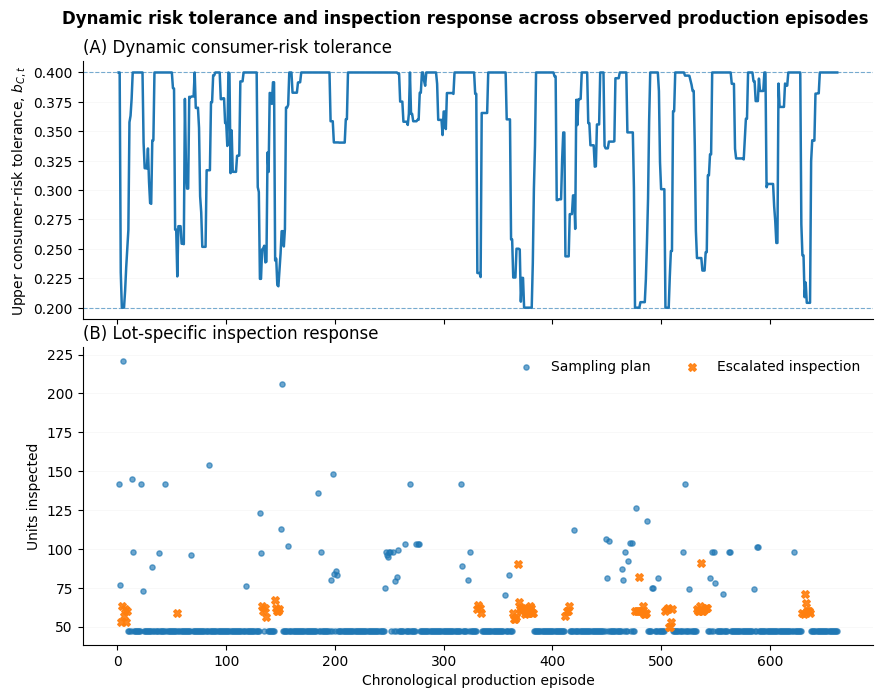

In [20]:
plot_df = (
    proposed
    .sort_values(["Start", "End"])
    .reset_index(drop=True)
    .copy()
)

plot_df["Episode"] = np.arange(
    1,
    len(plot_df) + 1
)

sampling_mask = (
    plot_df["Decision_Mode"] == "Sampling"
)

escalation_mask = (
    plot_df["Decision_Mode"]
    == "Escalated inspection"
)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10.2, 7.3),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1.0, 1.15],
        "hspace": 0.10,
    }
)

ax1.plot(
    plot_df["Episode"],
    plot_df["bC_t"],
    linewidth=1.8
)

ax1.axhline(
    0.40,
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

ax1.axhline(
    0.20,
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

ax1.set_ylabel(
    r"Upper consumer-risk tolerance, $b_{C,t}$"
)

ax1.set_title(
    "(A) Dynamic consumer-risk tolerance",
    loc="left"
)

ax2.scatter(
    plot_df.loc[sampling_mask, "Episode"],
    plot_df.loc[sampling_mask, "n_star"],
    s=14,
    alpha=0.65,
    label="Sampling plan"
)

ax2.scatter(
    plot_df.loc[escalation_mask, "Episode"],
    plot_df.loc[escalation_mask, "N"],
    s=30,
    marker="X",
    alpha=0.90,
    label="Escalated inspection"
)

ax2.set_xlabel(
    "Chronological production episode"
)

ax2.set_ylabel(
    "Units inspected"
)

ax2.set_title(
    "(B) Lot-specific inspection response",
    loc="left"
)

ax2.legend(
    frameon=False,
    ncol=2
)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(
        axis="y",
        linewidth=0.4,
        alpha=0.15
    )

fig.suptitle(
    "Dynamic risk tolerance and inspection response across observed production episodes",
    y=0.98,
    fontweight="bold"
)

fig.subplots_adjust(top=0.91)

fig.savefig(
    FIG_DIR / "Figure1_Dynamic_Adaptation.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR / "Figure1_Dynamic_Adaptation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Manuscript Figure 2 — protection–inspection trade-off

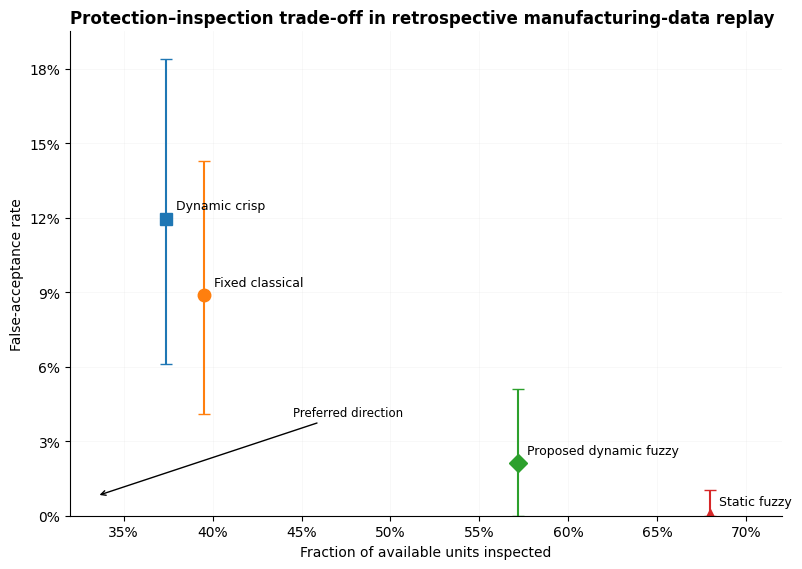

In [21]:
figure2_data = (
    primary_summary
    .groupby("Method")
    .agg(
        FA_mean=(
            "False_Accept_Rate",
            "mean"
        ),
        FA_low=(
            "False_Accept_Rate",
            lambda x: x.quantile(0.025)
        ),
        FA_high=(
            "False_Accept_Rate",
            lambda x: x.quantile(0.975)
        ),
        Inspection=(
            "Inspection_Fraction",
            "mean"
        ),
    )
    .reset_index()
)

markers = {
    "Dynamic crisp": "s",
    "Fixed classical": "o",
    "Proposed dynamic fuzzy": "D",
    "Static fuzzy": "^",
}

fig, ax = plt.subplots(
    figsize=(8.2, 5.8)
)

for _, row in figure2_data.iterrows():
    lower = (
        row["FA_mean"] - row["FA_low"]
    )

    upper = (
        row["FA_high"] - row["FA_mean"]
    )

    ax.errorbar(
        row["Inspection"],
        row["FA_mean"],
        yerr=np.array(
            [[lower], [upper]]
        ),
        fmt=markers[row["Method"]],
        markersize=9,
        capsize=4
    )

    ax.annotate(
        row["Method"],
        (
            row["Inspection"],
            row["FA_mean"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.annotate(
    "Preferred direction",
    xy=(0.335, 0.008),
    xytext=(0.445, 0.040),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.0
    },
    fontsize=8.5
)

ax.set_xlabel(
    "Fraction of available units inspected"
)

ax.set_ylabel(
    "False-acceptance rate"
)

ax.set_title(
    "Protection–inspection trade-off in retrospective manufacturing-data replay",
    loc="left",
    fontweight="bold"
)

ax.set_xlim(0.32, 0.72)
ax.set_ylim(0, 0.195)

ax.set_xticks(
    np.arange(0.35, 0.71, 0.05)
)

ax.set_xticklabels(
    [
        f"{100*x:.0f}%"
        for x in np.arange(
            0.35,
            0.71,
            0.05
        )
    ]
)

ax.set_yticks(
    np.arange(0, 0.181, 0.03)
)

ax.set_yticklabels(
    [
        f"{100*y:.0f}%"
        for y in np.arange(
            0,
            0.181,
            0.03
        )
    ]
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    linewidth=0.4,
    alpha=0.15
)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "Figure2_Protection_Inspection.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR / "Figure2_Protection_Inspection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 21. Final A-to-Z reproducibility checklist

In [22]:
checks = pd.DataFrame([
    [
        "Source records",
        len(raw),
        80015
    ],
    [
        "Rows after embedded-header removal",
        len(clean),
        80000
    ],
    [
        "Exact duplicate raw records",
        n_exact_duplicates,
        5315
    ],
    [
        "Final production records",
        len(trimmed),
        74685
    ],
    [
        "Unique serial numbers",
        trimmed["Serial No."].nunique(),
        72885
    ],
    [
        "Original lot identifiers",
        trimmed["Lot No."].nunique(),
        866
    ],
    [
        "Defective records",
        int(trimmed["Defective"].sum()),
        933
    ],
    [
        "24-hour production episodes",
        len(episodes24),
        1227
    ],
    [
        "Primary eligible episodes",
        len(analysis),
        662
    ],
    [
        "Acceptable episodes",
        int(
            (
                analysis["True_Status"]
                == "Acceptable"
            ).sum()
        ),
        404
    ],
    [
        "Indifference episodes",
        int(
            (
                analysis["True_Status"]
                == "Indifference"
            ).sum()
        ),
        160
    ],
    [
        "Rejectable episodes",
        int(
            (
                analysis["True_Status"]
                == "Rejectable"
            ).sum()
        ),
        98
    ],
    [
        "Proposed sampling episodes",
        int(
            (
                proposed["Decision_Mode"]
                == "Sampling"
            ).sum()
        ),
        584
    ],
    [
        "Proposed escalations",
        int(
            (
                proposed["Decision_Mode"]
                == "Escalated inspection"
            ).sum()
        ),
        78
    ],
])

checks.columns = [
    "Checkpoint",
    "Observed",
    "Expected"
]

checks["Match"] = (
    checks["Observed"]
    == checks["Expected"]
)

display(checks)

checks.to_csv(
    TABLE_DIR / "REPRODUCIBILITY_CHECKPOINTS.csv",
    index=False
)

if checks["Match"].all():
    print(
        "✓ ALL DETERMINISTIC ARTICLE CHECKPOINTS MATCH"
    )
else:
    print(
        "⚠ CHECK DATASET VERSION OR PREPROCESSING"
    )

,Checkpoint,Observed,Expected,Match
0,Source records,80015,80015,True
1,Rows after embedded-header removal,80000,80000,True
2,Exact duplicate raw records,5315,5315,True
3,Final production records,74685,74685,True
4,Unique serial numbers,72885,72885,True
5,Original lot identifiers,866,866,True
6,Defective records,933,933,True
7,24-hour production episodes,1227,1227,True
8,Primary eligible episodes,662,662,True
9,Acceptable episodes,404,404,True


✓ ALL DETERMINISTIC ARTICLE CHECKPOINTS MATCH


#### further analysis 

In [24]:
# ============================================================
# FINAL DECISION-POLICY CALIBRATION SENSITIVITY ANALYSIS
# Dynamic Fuzzy Acceptance Sampling
#
# PURPOSE
# -------
# Test whether the main protection-inspection conclusion depends
# on the particular fuzzy/decision-policy calibration.
#
# PRIMARY DESIGN REMAINS FROZEN:
# pA = 0.01
# pR = 0.03
# K = 10
# Nmin = 50
# 24-hour production episodes already constructed
#
# THREE SENSITIVITY BLOCKS:
# A. etaP x etaC
# B. rho (= inspection_cost/lambda) x wC
# C. bC_base x q, where q = bC_min / bC_base
#
# IMPORTANT:
# - Parameters not being varied remain at primary values.
# - Comparators are recalibrated consistently where appropriate.
# - Common Monte Carlo samples are used across ALL scenarios.
# - Primary specification is NOT re-optimized.
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import binom

# ============================================================
# 1. PATHS
# ============================================================

folder = Path("/Users/muhammadzahirkhan")

unit_file = folder / "PROD_DS_PD_EPISODES.csv"
episode_file = folder / "ANALYSIS_EPISODES_N50.csv"

output_full = folder / "CALIBRATION_SENSITIVITY_FULL.csv"
output_summary = folder / "CALIBRATION_SENSITIVITY_SUMMARY.csv"
output_robust = folder / "CALIBRATION_ROBUSTNESS_PROPORTIONS.csv"

# ============================================================
# 2. LOAD DATA
# ============================================================

units = pd.read_csv(
    unit_file,
    parse_dates=["DateTime"],
    low_memory=False
)

episodes = pd.read_csv(
    episode_file,
    parse_dates=["Start", "End"],
    low_memory=False
)

episodes = (
    episodes
    .sort_values(["Start", "End"])
    .reset_index(drop=True)
)

# Keep exactly the primary N >= 50 episodes
episodes = episodes[episodes["N"] >= 50].copy()
episodes = episodes.reset_index(drop=True)

valid_episodes = set(episodes["Production_Episode"])

units = units[
    units["Production_Episode"].isin(valid_episodes)
].copy()

print("=" * 80)
print("CALIBRATION SENSITIVITY ANALYSIS")
print("=" * 80)
print("Eligible episodes:", len(episodes))
print("Available unit records:", len(units))

# ============================================================
# 3. FROZEN PRIMARY DESIGN
# ============================================================

pA = 0.01
pR = 0.03
K = 10
Nmin = 50

# Producer fuzzy preference is NOT varied
aP = 0.20
bP = 0.40

# Primary decision-policy values
PRIMARY = {
    "etaP": 0.10,
    "etaC": 0.10,
    "rho": 0.001,      # rho = kappa/lambda
    "wC": 0.50,
    "bC_base": 0.40,
    "q": 0.50
}

# lambda can be fixed at 1 because only kappa/lambda matters
lambda_penalty = 1.0

# Monte Carlo sensitivity screening
B = 300
BASE_SEED = 20260828

# ============================================================
# 4. TRUE RETROSPECTIVE QUALITY STATUS
# ============================================================

episodes["True_Status"] = np.select(
    [
        episodes["Defect_Rate"] <= pA,
        episodes["Defect_Rate"] >= pR
    ],
    [
        "Acceptable",
        "Rejectable"
    ],
    default="Indifference"
)

print("\nTrue episode status:")
print(episodes["True_Status"].value_counts())

n_A = int((episodes["True_Status"] == "Acceptable").sum())
n_R = int((episodes["True_Status"] == "Rejectable").sum())

print("\nAcceptable episodes :", n_A)
print("Rejectable episodes :", n_R)
print("Indifference episodes:",
      int((episodes["True_Status"] == "Indifference").sum()))

# ============================================================
# 5. FUZZY SATISFACTION
# ============================================================

def fuzzy_satisfaction(risk, a, b):
    if risk <= a:
        return 1.0
    if risk >= b:
        return 0.0
    return (b - risk) / (b - a)

# ============================================================
# 6. PRECOMPUTE RECENT HISTORY
#
# EXACTLY MATCHES FINAL V2 LOGIC:
# - only previous episodes
# - only episodes completed before current start
# - most recent K = 10 completed episodes
# ============================================================

history_rows = []

for idx, row in episodes.iterrows():

    start_t = row["Start"]

    completed = episodes.iloc[:idx].copy()

    completed = completed[
        completed["End"] < start_t
    ]

    completed = (
        completed
        .sort_values("End")
        .tail(K)
    )

    if len(completed) == 0:
        Ht = pA
    else:
        hist_N = completed["N"].sum()
        hist_D = completed["Defective"].sum()
        Ht = hist_D / hist_N

    Dt = (Ht - pA) / (pR - pA)
    Dt = float(np.clip(Dt, 0.0, 1.0))

    history_rows.append({
        "Production_Episode": row["Production_Episode"],
        "Historical_Defect_Rate": Ht,
        "Deterioration_Index": Dt,
        "Recent_History_N": len(completed)
    })

history = pd.DataFrame(history_rows)

episodes = episodes.merge(
    history,
    on="Production_Episode",
    how="left"
)

# ============================================================
# 7. PRECOMPUTE BINOMIAL RISK ARRAYS
#
# Saves substantial computation because pA and pR remain fixed.
# ============================================================

unique_N = sorted(episodes["N"].astype(int).unique())

risk_cache = {}

for max_n in unique_N:

    risk_cache[max_n] = {}

    for n in range(1, max_n + 1):

        c_values = np.arange(n)

        alpha_values = (
            1.0 -
            binom.cdf(c_values, n, pA)
        )

        beta_values = binom.cdf(
            c_values,
            n,
            pR
        )

        risk_cache[max_n][n] = (
            c_values,
            alpha_values,
            beta_values
        )

print("\nRisk calculations cached.")

# ============================================================
# 8. FIXED CLASSICAL COMPARATOR
#
# Universally implementable plan for Nmin = 50.
# Minimize max(alpha,beta), then alpha+beta, then n.
# ============================================================

def fixed_classical_plan():

    candidates = []

    for n in range(1, Nmin + 1):

        c_values = np.arange(n)

        alpha_values = (
            1 -
            binom.cdf(c_values, n, pA)
        )

        beta_values = binom.cdf(
            c_values, n, pR
        )

        for j, c in enumerate(c_values):

            alpha = float(alpha_values[j])
            beta = float(beta_values[j])

            candidates.append({
                "n": int(n),
                "c": int(c),
                "alpha": alpha,
                "beta": beta,
                "maxrisk": max(alpha, beta),
                "sumrisk": alpha + beta
            })

    cand = pd.DataFrame(candidates)

    best = (
        cand
        .sort_values(
            ["maxrisk", "sumrisk", "n", "c"]
        )
        .iloc[0]
    )

    return {
        "mode": "Sampling",
        "n": int(best["n"]),
        "c": int(best["c"])
    }

FIXED_PLAN = fixed_classical_plan()

print("\nFixed classical plan:")
print(FIXED_PLAN)

# Expected primary result: approximately (38, 0)

# ============================================================
# 9. STATIC FUZZY PLAN
#
# Recalibrated with eta/rho/wC/bC_base when those quantities
# are varied. This preserves comparator fairness.
# ============================================================

def static_fuzzy_plan(
    Nt,
    etaP,
    etaC,
    rho,
    wC,
    bC_base
):

    wP = 1.0 - wC

    # Static fuzzy interval uses baseline consumer tolerance.
    aC = 0.50 * bC_base
    bC = bC_base

    best = None

    for n in range(1, Nt + 1):

        # Lower bound on objective at this and later n.
        # If already worse than current best, stop safely.
        if best is not None:
            if rho * n > best["J"] + 1e-14:
                break

        c_values = np.arange(n)

        alpha_values = (
            1 -
            binom.cdf(c_values, n, pA)
        )

        beta_values = binom.cdf(
            c_values, n, pR
        )

        for j, c in enumerate(c_values):

            alpha = float(alpha_values[j])
            beta = float(beta_values[j])

            SP = fuzzy_satisfaction(
                alpha,
                aP,
                bP
            )

            SC = fuzzy_satisfaction(
                beta,
                aC,
                bC
            )

            if SP < etaP or SC < etaC:
                continue

            J = (
                rho * n
                +
                wP * (1.0 - SP)
                +
                wC * (1.0 - SC)
            )

            candidate = {
                "mode": "Sampling",
                "n": int(n),
                "c": int(c),
                "J": float(J),
                "alpha": alpha,
                "beta": beta
            }

            if best is None:
                best = candidate
            else:
                new_key = (
                    candidate["J"],
                    candidate["n"],
                    candidate["beta"],
                    candidate["alpha"]
                )

                old_key = (
                    best["J"],
                    best["n"],
                    best["beta"],
                    best["alpha"]
                )

                if new_key < old_key:
                    best = candidate

    if best is None:
        return {
            "mode": "Escalated inspection",
            "n": int(Nt),
            "c": np.nan
        }

    return best

# ============================================================
# 10. DYNAMIC CRISP PLAN
#
# Uses SAME dynamic bC_t as proposed method.
# Thus Block C changes the common history-adaptive tolerance
# for both proposed and dynamic-crisp methods.
# ============================================================

def dynamic_crisp_plan(
    Nt,
    beta_limit
):

    alpha_limit = 0.40

    for n in range(1, Nt + 1):

        c_values = np.arange(n)

        alpha_values = (
            1 -
            binom.cdf(c_values, n, pA)
        )

        beta_values = binom.cdf(
            c_values, n, pR
        )

        mask = (
            (alpha_values <= alpha_limit)
            &
            (beta_values <= beta_limit)
        )

        if not mask.any():
            continue

        feasible_c = c_values[mask]
        feasible_alpha = alpha_values[mask]
        feasible_beta = beta_values[mask]

        risk_sum = (
            feasible_alpha +
            feasible_beta
        )

        j = np.argmin(risk_sum)

        return {
            "mode": "Sampling",
            "n": int(n),
            "c": int(feasible_c[j])
        }

    return {
        "mode": "Escalated inspection",
        "n": int(Nt),
        "c": np.nan
    }

# ============================================================
# 11. PROPOSED DYNAMIC FUZZY PLAN
# ============================================================

def proposed_dynamic_fuzzy_plan(
    Nt,
    bCt,
    etaP,
    etaC,
    rho,
    wC
):

    wP = 1.0 - wC
    aCt = 0.50 * bCt

    best = None

    for n in range(1, Nt + 1):

        # Objective lower bound at current/larger n
        if best is not None:
            if rho * n > best["J"] + 1e-14:
                break

        c_values = np.arange(n)

        alpha_values = (
            1 -
            binom.cdf(c_values, n, pA)
        )

        beta_values = binom.cdf(
            c_values, n, pR
        )

        for j, c in enumerate(c_values):

            alpha = float(alpha_values[j])
            beta = float(beta_values[j])

            SP = fuzzy_satisfaction(
                alpha,
                aP,
                bP
            )

            SC = fuzzy_satisfaction(
                beta,
                aCt,
                bCt
            )

            if SP < etaP or SC < etaC:
                continue

            J = (
                rho * n
                +
                wP * (1.0 - SP)
                +
                wC * (1.0 - SC)
            )

            candidate = {
                "mode": "Sampling",
                "n": int(n),
                "c": int(c),
                "J": float(J),
                "alpha": alpha,
                "beta": beta
            }

            if best is None:
                best = candidate

            else:

                # Same substantive ordering as final V2:
                # objective -> n -> beta -> alpha
                new_key = (
                    candidate["J"],
                    candidate["n"],
                    candidate["beta"],
                    candidate["alpha"]
                )

                old_key = (
                    best["J"],
                    best["n"],
                    best["beta"],
                    best["alpha"]
                )

                if new_key < old_key:
                    best = candidate

    if best is None:

        return {
            "mode": "Escalated inspection",
            "n": int(Nt),
            "c": np.nan
        }

    return best

# ============================================================
# 12. DEFINE CALIBRATION SCENARIOS
# ============================================================

scenario_rows = []

# ------------------------------------------------------------
# BLOCK A: FUZZY SATISFACTION THRESHOLDS
# ------------------------------------------------------------

for etaP in [0.05, 0.10, 0.20]:
    for etaC in [0.05, 0.10, 0.20]:

        scenario_rows.append({
            "Block": "Satisfaction thresholds",
            "etaP": etaP,
            "etaC": etaC,
            "rho": PRIMARY["rho"],
            "wC": PRIMARY["wC"],
            "bC_base": PRIMARY["bC_base"],
            "q": PRIMARY["q"]
        })

# ------------------------------------------------------------
# BLOCK B: OBJECTIVE CALIBRATION
# ------------------------------------------------------------

for rho in [0.0005, 0.001, 0.002, 0.005]:
    for wC in [0.25, 0.50, 0.75]:

        scenario_rows.append({
            "Block": "Objective calibration",
            "etaP": PRIMARY["etaP"],
            "etaC": PRIMARY["etaC"],
            "rho": rho,
            "wC": wC,
            "bC_base": PRIMARY["bC_base"],
            "q": PRIMARY["q"]
        })

# ------------------------------------------------------------
# BLOCK C: CONSUMER-RISK INTERVAL
# ------------------------------------------------------------

for bC_base in [0.35, 0.40, 0.45]:
    for q in [0.40, 0.50, 0.60]:

        scenario_rows.append({
            "Block": "Consumer-risk interval",
            "etaP": PRIMARY["etaP"],
            "etaC": PRIMARY["etaC"],
            "rho": PRIMARY["rho"],
            "wC": PRIMARY["wC"],
            "bC_base": bC_base,
            "q": q
        })

scenarios = pd.DataFrame(scenario_rows)

scenarios["Scenario"] = [
    f"S{i:02d}"
    for i in range(1, len(scenarios) + 1)
]

# Primary flag
scenarios["Primary"] = (
    np.isclose(scenarios["etaP"], PRIMARY["etaP"])
    &
    np.isclose(scenarios["etaC"], PRIMARY["etaC"])
    &
    np.isclose(scenarios["rho"], PRIMARY["rho"])
    &
    np.isclose(scenarios["wC"], PRIMARY["wC"])
    &
    np.isclose(scenarios["bC_base"], PRIMARY["bC_base"])
    &
    np.isclose(scenarios["q"], PRIMARY["q"])
)

print("\nCalibration scenarios:", len(scenarios))
print("\nScenarios by block:")
print(scenarios["Block"].value_counts())

# ============================================================
# 13. PRE-GROUP OBSERVED UNIT DATA
# ============================================================

episode_groups = {
    ep: g.sort_values("DateTime")
         .reset_index(drop=True)
    for ep, g in units.groupby("Production_Episode")
}

status_lookup = (
    episodes
    .set_index("Production_Episode")["True_Status"]
    .to_dict()
)

N_lookup = (
    episodes
    .set_index("Production_Episode")["N"]
    .astype(int)
    .to_dict()
)

D_lookup = (
    episodes
    .set_index("Production_Episode")["Defective"]
    .astype(int)
    .to_dict()
)

Dt_lookup = (
    episodes
    .set_index("Production_Episode")["Deterioration_Index"]
    .to_dict()
)

episode_order = episodes["Production_Episode"].tolist()

total_available_units = int(episodes["N"].sum())

# ============================================================
# 14. PRECOMPUTE COMMON RANDOMIZED PRODUCTION REPLAYS
#
# Each scenario sees EXACTLY the same randomized ordering.
# This avoids Monte Carlo differences being mistaken for
# calibration effects.
#
# cumulative_defects[episode] has shape B x N.
# ============================================================

print("\nPrecomputing common Monte Carlo replay samples...")

rng = np.random.default_rng(BASE_SEED)

cumulative_defects = {}

for i, ep in enumerate(episode_order, start=1):

    g = episode_groups[ep]

    defect_vector = (
        g["Defective"]
        .astype(np.uint16)
        .to_numpy()
    )

    N = len(defect_vector)

    temp = np.empty(
        (B, N),
        dtype=np.uint16
    )

    for b in range(B):

        randomized = rng.permutation(
            defect_vector
        )

        temp[b, :] = np.cumsum(
            randomized,
            dtype=np.uint16
        )

    cumulative_defects[ep] = temp

    if i % 100 == 0:
        print(
            f"  Prepared {i}/{len(episode_order)} episodes"
        )

print("Common replay samples complete.")

# ============================================================
# 15. RUN ONE CALIBRATION SCENARIO
# ============================================================

METHODS = [
    "Fixed classical",
    "Dynamic crisp",
    "Static fuzzy",
    "Proposed dynamic fuzzy"
]

def run_calibration_scenario(s):

    etaP = float(s["etaP"])
    etaC = float(s["etaC"])
    rho = float(s["rho"])
    wC = float(s["wC"])
    bC_base = float(s["bC_base"])
    q = float(s["q"])

    bC_min = q * bC_base

    gamma = np.log(
        bC_base / bC_min
    )

    # ---------------------------------------------
    # Replay-level FA/FR counters
    # ---------------------------------------------

    FA = {
        m: np.zeros(B, dtype=int)
        for m in METHODS
    }

    FR = {
        m: np.zeros(B, dtype=int)
        for m in METHODS
    }

    total_inspected = {
        m: 0
        for m in METHODS
    }

    escalated = {
        m: 0
        for m in METHODS
    }

    # ---------------------------------------------
    # Process episodes
    # ---------------------------------------------

    for ep in episode_order:

        Nt = N_lookup[ep]
        Dt = Dt_lookup[ep]
        status = status_lookup[ep]

        # Dynamic consumer tolerance
        bCt = (
            bC_base *
            np.exp(-gamma * Dt)
        )

        bCt = float(
            np.clip(
                bCt,
                bC_min,
                bC_base
            )
        )

        # -----------------------------------------
        # Plans
        # -----------------------------------------

        plans = {}

        plans["Fixed classical"] = FIXED_PLAN

        plans["Dynamic crisp"] = dynamic_crisp_plan(
            Nt=Nt,
            beta_limit=bCt
        )

        plans["Static fuzzy"] = static_fuzzy_plan(
            Nt=Nt,
            etaP=etaP,
            etaC=etaC,
            rho=rho,
            wC=wC,
            bC_base=bC_base
        )

        plans["Proposed dynamic fuzzy"] = (
            proposed_dynamic_fuzzy_plan(
                Nt=Nt,
                bCt=bCt,
                etaP=etaP,
                etaC=etaC,
                rho=rho,
                wC=wC
            )
        )

        cum = cumulative_defects[ep]

        # -----------------------------------------
        # Evaluate all methods with SAME ordering
        # -----------------------------------------

        for method in METHODS:

            plan = plans[method]

            if plan["mode"] == "Escalated inspection":

                escalated[method] += 1
                total_inspected[method] += Nt

                # Full inspection reveals true status,
                # therefore no FA/FR is generated here.
                continue

            n = int(plan["n"])
            c = int(plan["c"])

            total_inspected[method] += n

            sampled_defects = cum[:, n - 1]

            accepted = (
                sampled_defects <= c
            )

            if status == "Rejectable":
                FA[method] += accepted.astype(int)

            elif status == "Acceptable":
                FR[method] += (~accepted).astype(int)

    # ---------------------------------------------
    # Summaries
    # ---------------------------------------------

    rows = []

    for method in METHODS:

        FA_rate = FA[method] / n_R
        FR_rate = FR[method] / n_A

        rows.append({
            "Scenario": s["Scenario"],
            "Block": s["Block"],
            "Primary": bool(s["Primary"]),

            "etaP": etaP,
            "etaC": etaC,
            "rho": rho,
            "wP": 1.0 - wC,
            "wC": wC,

            "bC_base": bC_base,
            "q": q,
            "bC_min": bC_min,

            "Method": method,

            "FA": FA_rate.mean(),
            "FA_SD": FA_rate.std(ddof=1),
            "FA_Low": np.quantile(
                FA_rate, 0.025
            ),
            "FA_High": np.quantile(
                FA_rate, 0.975
            ),

            "FR": FR_rate.mean(),
            "FR_SD": FR_rate.std(ddof=1),
            "FR_Low": np.quantile(
                FR_rate, 0.025
            ),
            "FR_High": np.quantile(
                FR_rate, 0.975
            ),

            "Total_Inspected":
                total_inspected[method],

            "Inspection":
                total_inspected[method]
                / total_available_units,

            "ASN":
                total_inspected[method]
                / len(episodes),

            "Escalated":
                escalated[method]
        })

    return pd.DataFrame(rows)

# ============================================================
# 16. RUN ALL 30 BLOCK-SPECIFIC SCENARIOS
# ============================================================

all_results = []

for i, (_, s) in enumerate(
    scenarios.iterrows(),
    start=1
):

    print(
        f"\nRunning calibration scenario "
        f"{i}/{len(scenarios)}: "
        f"{s['Scenario']} | {s['Block']}"
    )

    result = run_calibration_scenario(s)

    all_results.append(result)

results = pd.concat(
    all_results,
    ignore_index=True
)

results.to_csv(
    output_full,
    index=False
)

# ============================================================
# 17. PRIMARY-SPECIFICATION VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("PRIMARY SPECIFICATION VALIDATION")
print("=" * 80)

primary_rows = results[
    results["Primary"]
].copy()

# Primary appears once in each block.
# All three should return identical results.
print(
    primary_rows[
        [
            "Block",
            "Method",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nExpected published primary benchmarks:")
print("Dynamic crisp           FA≈0.1196, FR≈0.0057, Inspection≈0.3740")
print("Fixed classical         FA≈0.0890, FR≈0.0066, Inspection≈0.3952")
print("Proposed dynamic fuzzy  FA≈0.0209, FR≈0.0004, Inspection≈0.5715, ASN≈54.95, Escalated=78")
print("Static fuzzy            FA≈0.0004, FR≈0.0006, Inspection≈0.6794, Escalated=651")
print("\nNOTE: FA/FR may differ slightly because this sensitivity analysis uses 300 replays.")
print("Inspection, ASN and escalation should reproduce the primary plan structure.")

# ============================================================
# 18. BLOCK-WISE RANGE SUMMARY
# ============================================================

proposed = results[
    results["Method"] == "Proposed dynamic fuzzy"
].copy()

block_summary = (
    proposed
    .groupby("Block")
    .agg(
        FA_min=("FA", "min"),
        FA_max=("FA", "max"),
        FR_min=("FR", "min"),
        FR_max=("FR", "max"),
        Inspection_min=("Inspection", "min"),
        Inspection_max=("Inspection", "max"),
        ASN_min=("ASN", "min"),
        ASN_max=("ASN", "max"),
        Escalated_min=("Escalated", "min"),
        Escalated_max=("Escalated", "max")
    )
    .reset_index()
)

block_summary.to_csv(
    output_summary,
    index=False
)

print("\n" + "=" * 80)
print("CALIBRATION SENSITIVITY — RANGE SUMMARY")
print("=" * 80)

print(
    block_summary
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 19. CONFIGURATION-LEVEL ROBUSTNESS
#
# Compare methods within each calibration specification.
# ============================================================

wide = results.pivot_table(
    index=[
        "Scenario",
        "Block",
        "Primary",
        "etaP",
        "etaC",
        "rho",
        "wC",
        "bC_base",
        "q"
    ],
    columns="Method",
    values=[
        "FA",
        "FR",
        "Inspection",
        "ASN",
        "Escalated"
    ]
)

wide.columns = [
    f"{metric}__{method}"
    for metric, method in wide.columns
]

wide = wide.reset_index()

wide["Lower_FA_than_Fixed"] = (
    wide["FA__Proposed dynamic fuzzy"]
    <
    wide["FA__Fixed classical"]
)

wide["Lower_FA_than_Dynamic_Crisp"] = (
    wide["FA__Proposed dynamic fuzzy"]
    <
    wide["FA__Dynamic crisp"]
)

wide["Lower_Inspection_than_Static_Fuzzy"] = (
    wide["Inspection__Proposed dynamic fuzzy"]
    <
    wide["Inspection__Static fuzzy"]
)

wide["Fewer_Escalations_than_Static_Fuzzy"] = (
    wide["Escalated__Proposed dynamic fuzzy"]
    <
    wide["Escalated__Static fuzzy"]
)

# ============================================================
# 20. REMOVE DUPLICATED PRIMARY CONFIGURATION FOR OVERALL
# ROBUSTNESS PROPORTIONS
#
# The primary parameter set occurs once in each of the 3 blocks.
# We count it only once in the overall robustness proportion.
# ============================================================

parameter_cols = [
    "etaP",
    "etaC",
    "rho",
    "wC",
    "bC_base",
    "q"
]

unique_configs = (
    wide
    .drop_duplicates(
        subset=parameter_cols,
        keep="first"
    )
    .copy()
)

robustness_rows = []

conditions = {
    "Lower FA than fixed classical":
        "Lower_FA_than_Fixed",

    "Lower FA than dynamic crisp":
        "Lower_FA_than_Dynamic_Crisp",

    "Lower inspection than static fuzzy":
        "Lower_Inspection_than_Static_Fuzzy",

    "Fewer escalations than static fuzzy":
        "Fewer_Escalations_than_Static_Fuzzy"
}

for label, col in conditions.items():

    count = int(
        unique_configs[col].sum()
    )

    total = len(unique_configs)

    robustness_rows.append({
        "Criterion": label,
        "Configurations_satisfying": count,
        "Total_unique_configurations": total,
        "Robustness_Proportion":
            count / total
    })

robustness = pd.DataFrame(
    robustness_rows
)

robustness.to_csv(
    output_robust,
    index=False
)

print("\n" + "=" * 80)
print("CONFIGURATION ROBUSTNESS PROPORTIONS")
print("=" * 80)

print(
    robustness
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 21. SHOW EACH PROPOSED CALIBRATION SPECIFICATION
# ============================================================

print("\n" + "=" * 80)
print("PROPOSED METHOD — ALL CALIBRATION SETTINGS")
print("=" * 80)

show_cols = [
    "Scenario",
    "Block",
    "etaP",
    "etaC",
    "rho",
    "wC",
    "bC_base",
    "q",
    "FA",
    "FR",
    "Inspection",
    "ASN",
    "Escalated"
]

print(
    proposed[
        show_cols
    ]
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 22. DIRECTIONAL SUMMARIES
# ============================================================

print("\n" + "=" * 80)
print("BLOCK A — SATISFACTION THRESHOLDS")
print("=" * 80)

block_A = proposed[
    proposed["Block"] ==
    "Satisfaction thresholds"
][
    [
        "etaP",
        "etaC",
        "FA",
        "FR",
        "Inspection",
        "ASN",
        "Escalated"
    ]
].sort_values(
    ["etaP", "etaC"]
)

print(
    block_A
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("BLOCK B — OBJECTIVE CALIBRATION")
print("=" * 80)

block_B = proposed[
    proposed["Block"] ==
    "Objective calibration"
][
    [
        "rho",
        "wC",
        "FA",
        "FR",
        "Inspection",
        "ASN",
        "Escalated"
    ]
].sort_values(
    ["rho", "wC"]
)

print(
    block_B
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("BLOCK C — CONSUMER-RISK INTERVAL")
print("=" * 80)

block_C = proposed[
    proposed["Block"] ==
    "Consumer-risk interval"
][
    [
        "bC_base",
        "q",
        "bC_min",
        "FA",
        "FR",
        "Inspection",
        "ASN",
        "Escalated"
    ]
].sort_values(
    ["bC_base", "q"]
)

print(
    block_C
    .round(4)
    .to_string(index=False)
)

# ============================================================
# 23. AUTOMATIC INTERPRETATION CHECK
# ============================================================

n_unique = len(unique_configs)

n_fixed = int(
    unique_configs[
        "Lower_FA_than_Fixed"
    ].sum()
)

n_crisp = int(
    unique_configs[
        "Lower_FA_than_Dynamic_Crisp"
    ].sum()
)

n_static_inspection = int(
    unique_configs[
        "Lower_Inspection_than_Static_Fuzzy"
    ].sum()
)

n_static_escalation = int(
    unique_configs[
        "Fewer_Escalations_than_Static_Fuzzy"
    ].sum()
)

print("\n" + "=" * 80)
print("MANUSCRIPT INTERPRETATION CHECK")
print("=" * 80)

print(
    f"\nLower FA than fixed classical: "
    f"{n_fixed}/{n_unique} "
    f"({100*n_fixed/n_unique:.1f}%)"
)

print(
    f"Lower FA than dynamic crisp: "
    f"{n_crisp}/{n_unique} "
    f"({100*n_crisp/n_unique:.1f}%)"
)

print(
    f"Lower inspection than static fuzzy: "
    f"{n_static_inspection}/{n_unique} "
    f"({100*n_static_inspection/n_unique:.1f}%)"
)

print(
    f"Fewer escalations than static fuzzy: "
    f"{n_static_escalation}/{n_unique} "
    f"({100*n_static_escalation/n_unique:.1f}%)"
)

# ============================================================
# 24. SIMPLE DECISION RULE FOR CLAIM STRENGTH
# ============================================================

prop_fixed = n_fixed / n_unique
prop_crisp = n_crisp / n_unique
prop_static = n_static_inspection / n_unique

print("\n" + "-" * 80)

if (
    prop_fixed >= 0.80
    and
    prop_crisp >= 0.80
    and
    prop_static >= 0.80
):
    print(
        "RESULT: STRONG calibration robustness."
    )
    print(
        "The manuscript can reasonably state that the "
        "principal protection-inspection pattern was "
        "not confined to the primary calibration."
    )

elif (
    prop_fixed >= 0.60
    and
    prop_crisp >= 0.60
):
    print(
        "RESULT: MODERATE calibration robustness."
    )
    print(
        "Use cautious wording such as "
        "'generally persisted across alternative calibrations'."
    )

else:
    print(
        "RESULT: CALIBRATION SENSITIVITY IS SUBSTANTIAL."
    )
    print(
        "Do NOT claim broad robustness. "
        "Report which parameter regions change the conclusion."
    )

print("-" * 80)

# ============================================================
# 25. SAVE CONFIGURATION COMPARISON AS EXTRA FILE
# ============================================================

wide_output = (
    folder /
    "CALIBRATION_CONFIGURATION_COMPARISONS.csv"
)

wide.to_csv(
    wide_output,
    index=False
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(output_full)
print(output_summary)
print(output_robust)
print(wide_output)

print("\nCALIBRATION SENSITIVITY ANALYSIS COMPLETE.")

CALIBRATION SENSITIVITY ANALYSIS
Eligible episodes: 662
Available unit records: 63652

True episode status:
True_Status
Acceptable      404
Indifference    160
Rejectable       98
Name: count, dtype: int64

Acceptable episodes : 404
Rejectable episodes : 98
Indifference episodes: 160

Risk calculations cached.

Fixed classical plan:
{'mode': 'Sampling', 'n': 38, 'c': 0}

Calibration scenarios: 30

Scenarios by block:
Block
Objective calibration      12
Satisfaction thresholds     9
Consumer-risk interval      9
Name: count, dtype: int64

Precomputing common Monte Carlo replay samples...
  Prepared 100/662 episodes
  Prepared 200/662 episodes
  Prepared 300/662 episodes
  Prepared 400/662 episodes
  Prepared 500/662 episodes
  Prepared 600/662 episodes
Common replay samples complete.

Running calibration scenario 1/30: S01 | Satisfaction thresholds

Running calibration scenario 2/30: S02 | Satisfaction thresholds

Running calibration scenario 3/30: S03 | Satisfaction thresholds

Running

In [25]:
# =============================================================================
# FINAL CORRECTED DECISION-POLICY CALIBRATION SENSITIVITY ANALYSIS
# Dynamic Fuzzy Acceptance Sampling
#
# CORRECTION:
# Static fuzzy is a GLOBAL history-independent comparator:
#   1. Optimize ONE static fuzzy (n,c) plan per calibration specification.
#   2. Apply that same plan to every eligible production episode.
#   3. If Nt < required static sample size n, escalate that episode.
#
# This reproduces the definition used in the validated main comparison.
#
# PRIMARY DESIGN:
# pA   = 0.01
# pR   = 0.03
# K    = 10
# Nmin = 50
#
# PRIMARY POLICY:
# etaP = etaC = 0.10
# rho = kappa/lambda = 0.001
# wP = wC = 0.50
# bC_base = 0.40
# bC_min  = 0.20
# q = bC_min / bC_base = 0.50
#
# CALIBRATION BLOCKS:
# A. etaP x etaC
# B. rho x wC
# C. bC_base x q
#
# Monte Carlo:
# B = 300 replays per calibration specification
# Common randomized unit ordering across configurations
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import pandas as pd
import numpy as np

from pathlib import Path
from scipy.stats import binom


# =============================================================================
# 1. PATHS
# =============================================================================

folder = Path("/Users/muhammadzahirkhan")

unit_file = (
    folder /
    "PROD_DS_PD_EPISODES.csv"
)

episode_file = (
    folder /
    "ANALYSIS_EPISODES_N50.csv"
)

output_full = (
    folder /
    "CALIBRATION_SENSITIVITY_FULL_CORRECTED.csv"
)

output_summary = (
    folder /
    "CALIBRATION_SENSITIVITY_SUMMARY_CORRECTED.csv"
)

output_robust = (
    folder /
    "CALIBRATION_ROBUSTNESS_PROPORTIONS_CORRECTED.csv"
)

output_comparisons = (
    folder /
    "CALIBRATION_CONFIGURATION_COMPARISONS_CORRECTED.csv"
)

output_static_plans = (
    folder /
    "CALIBRATION_STATIC_FUZZY_PLANS_CORRECTED.csv"
)


# =============================================================================
# 2. LOAD PRIMARY DATA
# =============================================================================

units = pd.read_csv(
    unit_file,
    parse_dates=["DateTime"],
    low_memory=False
)

episodes = pd.read_csv(
    episode_file,
    parse_dates=["Start", "End"],
    low_memory=False
)

episodes = (
    episodes
    .sort_values(
        ["Start", "End"]
    )
    .reset_index(drop=True)
)

# -------------------------------------------------------------------------
# Explicitly retain the primary eligibility condition.
# ANALYSIS_EPISODES_N50.csv should already contain these,
# but this protects the analysis against accidental file changes.
# -------------------------------------------------------------------------

episodes = (
    episodes[
        episodes["N"] >= 50
    ]
    .copy()
    .reset_index(drop=True)
)

valid_episodes = set(
    episodes[
        "Production_Episode"
    ]
)

units = (
    units[
        units[
            "Production_Episode"
        ].isin(valid_episodes)
    ]
    .copy()
)

print("=" * 88)
print("CORRECTED CALIBRATION SENSITIVITY ANALYSIS")
print("=" * 88)

print(
    "\nEligible episodes:",
    len(episodes)
)

print(
    "Available unit records:",
    len(units)
)


# =============================================================================
# 3. FROZEN PRIMARY DESIGN
# =============================================================================

pA = 0.01
pR = 0.03

K = 10
Nmin = 50

# -------------------------------------------------------------------------
# Producer fuzzy preference remains fixed.
# -------------------------------------------------------------------------

aP = 0.20
bP = 0.40

# -------------------------------------------------------------------------
# Primary policy calibration.
# -------------------------------------------------------------------------

PRIMARY = {
    "etaP": 0.10,
    "etaC": 0.10,
    "rho": 0.001,
    "wC": 0.50,
    "bC_base": 0.40,
    "q": 0.50
}

# lambda fixed at unity.
# rho = kappa/lambda therefore directly becomes the inspection penalty.

lambda_penalty = 1.0

# -------------------------------------------------------------------------
# Monte Carlo robustness screening
# -------------------------------------------------------------------------

B = 300
BASE_SEED = 20260828


# =============================================================================
# 4. TRUE RETROSPECTIVE EPISODE STATUS
# =============================================================================

episodes[
    "True_Status"
] = np.select(
    [
        episodes[
            "Defect_Rate"
        ] <= pA,

        episodes[
            "Defect_Rate"
        ] >= pR
    ],
    [
        "Acceptable",
        "Rejectable"
    ],
    default="Indifference"
)

n_A = int(
    (
        episodes[
            "True_Status"
        ] == "Acceptable"
    ).sum()
)

n_R = int(
    (
        episodes[
            "True_Status"
        ] == "Rejectable"
    ).sum()
)

n_I = int(
    (
        episodes[
            "True_Status"
        ] == "Indifference"
    ).sum()
)

print(
    "\nTrue episode status:"
)

print(
    episodes[
        "True_Status"
    ].value_counts()
)

print(
    "\nAcceptable episodes :",
    n_A
)

print(
    "Rejectable episodes :",
    n_R
)

print(
    "Indifference episodes:",
    n_I
)


# =============================================================================
# 5. FUZZY SATISFACTION FUNCTION
# =============================================================================

def fuzzy_satisfaction(
    risk,
    a,
    b
):
    """
    Linear decreasing membership function.

    Satisfaction = 1 for risk <= a.
    Satisfaction = 0 for risk >= b.
    Linear transition between a and b.
    """

    if risk <= a:
        return 1.0

    if risk >= b:
        return 0.0

    return (
        (b - risk)
        /
        (b - a)
    )


# =============================================================================
# 6. PRECOMPUTE VALID RECENT HISTORY
#
# EXACT FINAL V2 LOGIC:
#
# - use only episodes preceding the current episode in sequence
# - require End < current Start
# - retain most recent K = 10 completed episodes
# =============================================================================

history_rows = []

for idx, row in episodes.iterrows():

    start_t = row[
        "Start"
    ]

    completed = (
        episodes
        .iloc[:idx]
        .copy()
    )

    completed = completed[
        completed[
            "End"
        ] < start_t
    ]

    completed = (
        completed
        .sort_values(
            "End"
        )
        .tail(K)
    )

    if len(
        completed
    ) == 0:

        Ht = pA

    else:

        hist_N = (
            completed[
                "N"
            ].sum()
        )

        hist_D = (
            completed[
                "Defective"
            ].sum()
        )

        Ht = (
            hist_D
            /
            hist_N
        )

    Dt = (
        (Ht - pA)
        /
        (pR - pA)
    )

    Dt = float(
        np.clip(
            Dt,
            0.0,
            1.0
        )
    )

    history_rows.append(
        {
            "Production_Episode":
                row[
                    "Production_Episode"
                ],

            "Historical_Defect_Rate":
                Ht,

            "Deterioration_Index":
                Dt,

            "Recent_History_N":
                len(completed)
        }
    )


history = pd.DataFrame(
    history_rows
)

episodes = episodes.merge(
    history,
    on="Production_Episode",
    how="left"
)

print(
    "\nHistory calculations complete."
)

print(
    "\nDeterioration-index summary:"
)

print(
    episodes[
        "Deterioration_Index"
    ].describe()
)


# =============================================================================
# 7. BINOMIAL RISK CACHE
#
# Because pA and pR do not change in this sensitivity experiment,
# alpha and beta for a given (n,c) can be cached.
# =============================================================================

max_episode_N = int(
    episodes[
        "N"
    ].max()
)

risk_cache = {}


def get_risks(n):
    """
    Return:
      c_values
      alpha_values
      beta_values

    for the specified sample size n.
    """

    if n not in risk_cache:

        c_values = np.arange(
            n
        )

        alpha_values = (
            1.0
            -
            binom.cdf(
                c_values,
                n,
                pA
            )
        )

        beta_values = (
            binom.cdf(
                c_values,
                n,
                pR
            )
        )

        risk_cache[n] = (
            c_values,
            alpha_values,
            beta_values
        )

    return risk_cache[n]


print(
    "\nMaximum eligible episode size:",
    max_episode_N
)


# =============================================================================
# 8. FIXED CLASSICAL COMPARATOR
#
# One globally implementable plan:
#
# n <= Nmin = 50
#
# Objective:
# 1. minimize max(alpha,beta)
# 2. then alpha + beta
# 3. then smaller n
# 4. then smaller c
# =============================================================================

def fixed_classical_plan():

    best = None

    for n in range(
        1,
        Nmin + 1
    ):

        (
            c_values,
            alpha_values,
            beta_values
        ) = get_risks(n)

        for j, c in enumerate(
            c_values
        ):

            alpha = float(
                alpha_values[j]
            )

            beta = float(
                beta_values[j]
            )

            candidate = {
                "mode":
                    "Sampling",

                "n":
                    int(n),

                "c":
                    int(c),

                "alpha":
                    alpha,

                "beta":
                    beta,

                "maxrisk":
                    max(
                        alpha,
                        beta
                    ),

                "sumrisk":
                    alpha + beta
            }

            if best is None:

                best = candidate

            else:

                new_key = (
                    candidate[
                        "maxrisk"
                    ],
                    candidate[
                        "sumrisk"
                    ],
                    candidate[
                        "n"
                    ],
                    candidate[
                        "c"
                    ]
                )

                old_key = (
                    best[
                        "maxrisk"
                    ],
                    best[
                        "sumrisk"
                    ],
                    best[
                        "n"
                    ],
                    best[
                        "c"
                    ]
                )

                if new_key < old_key:

                    best = candidate

    return best


FIXED_PLAN = (
    fixed_classical_plan()
)

print(
    "\nFixed classical plan:"
)

print(
    FIXED_PLAN
)

print(
    "\nExpected:",
    "(n,c) = (38,0)"
)


# =============================================================================
# 9. CORRECT STATIC FUZZY COMPARATOR
#
# CRITICAL:
#
# Static fuzzy is NOT optimized separately for each episode.
#
# For each calibration specification:
#
#   1. Find ONE globally optimal static fuzzy plan.
#   2. Use that exact (n,c) for every episode.
#   3. If Nt < static n, escalate that episode.
#
# Static consumer interval:
#
#   [0.5*bC_base, bC_base]
#
# It does NOT depend on q because q controls history-dependent tightening.
# =============================================================================

def find_global_static_fuzzy_plan(
    etaP,
    etaC,
    rho,
    wC,
    bC_base
):

    wP = (
        1.0 -
        wC
    )

    aC_static = (
        0.50 *
        bC_base
    )

    bC_static = (
        bC_base
    )

    best = None

    # ---------------------------------------------------------------------
    # Search up to largest available episode.
    #
    # The objective lower bound is rho*n because dissatisfaction
    # penalties are non-negative.
    #
    # Once rho*n exceeds the current best J, no larger n can improve J.
    # ---------------------------------------------------------------------

    for n in range(
        1,
        max_episode_N + 1
    ):

        if best is not None:

            lower_bound = (
                rho *
                n
            )

            if (
                lower_bound
                >
                best["J"]
                +
                1e-14
            ):

                break

        (
            c_values,
            alpha_values,
            beta_values
        ) = get_risks(n)

        for j, c in enumerate(
            c_values
        ):

            alpha = float(
                alpha_values[j]
            )

            beta = float(
                beta_values[j]
            )

            SP = (
                fuzzy_satisfaction(
                    alpha,
                    aP,
                    bP
                )
            )

            SC = (
                fuzzy_satisfaction(
                    beta,
                    aC_static,
                    bC_static
                )
            )

            if (
                SP < etaP
                or
                SC < etaC
            ):
                continue

            J = (
                rho *
                n
                +
                wP *
                (
                    1.0 -
                    SP
                )
                +
                wC *
                (
                    1.0 -
                    SC
                )
            )

            candidate = {
                "mode":
                    "Sampling",

                "n":
                    int(n),

                "c":
                    int(c),

                "alpha":
                    alpha,

                "beta":
                    beta,

                "SP":
                    SP,

                "SC":
                    SC,

                "J":
                    float(J)
            }

            if best is None:

                best = candidate

            else:

                new_key = (
                    candidate[
                        "J"
                    ],
                    candidate[
                        "n"
                    ],
                    candidate[
                        "beta"
                    ],
                    candidate[
                        "alpha"
                    ],
                    candidate[
                        "c"
                    ]
                )

                old_key = (
                    best[
                        "J"
                    ],
                    best[
                        "n"
                    ],
                    best[
                        "beta"
                    ],
                    best[
                        "alpha"
                    ],
                    best[
                        "c"
                    ]
                )

                if new_key < old_key:

                    best = candidate

    if best is None:

        raise RuntimeError(
            "No global static fuzzy plan "
            "was found for this calibration."
        )

    return best


# =============================================================================
# 10. DYNAMIC CRISP COMPARATOR
#
# Episode-specific because bC_t depends on recent production history.
#
# Producer hard limit remains alpha <= 0.40.
# Consumer hard limit is beta <= bC_t.
#
# Among first feasible n:
# minimize alpha + beta.
# =============================================================================

def dynamic_crisp_plan(
    Nt,
    beta_limit
):

    alpha_limit = (
        0.40
    )

    for n in range(
        1,
        Nt + 1
    ):

        (
            c_values,
            alpha_values,
            beta_values
        ) = get_risks(n)

        mask = (
            (
                alpha_values
                <=
                alpha_limit
            )
            &
            (
                beta_values
                <=
                beta_limit
            )
        )

        if not mask.any():
            continue

        feasible_c = (
            c_values[
                mask
            ]
        )

        feasible_alpha = (
            alpha_values[
                mask
            ]
        )

        feasible_beta = (
            beta_values[
                mask
            ]
        )

        risk_sum = (
            feasible_alpha
            +
            feasible_beta
        )

        j = int(
            np.argmin(
                risk_sum
            )
        )

        return {
            "mode":
                "Sampling",

            "n":
                int(n),

            "c":
                int(
                    feasible_c[
                        j
                    ]
                ),

            "alpha":
                float(
                    feasible_alpha[
                        j
                    ]
                ),

            "beta":
                float(
                    feasible_beta[
                        j
                    ]
                )
        }

    return {
        "mode":
            "Escalated inspection",

        "n":
            int(Nt),

        "c":
            np.nan,

        "alpha":
            np.nan,

        "beta":
            np.nan
    }


# =============================================================================
# 11. PROPOSED DYNAMIC FUZZY PLAN
# =============================================================================

def proposed_dynamic_fuzzy_plan(
    Nt,
    bCt,
    etaP,
    etaC,
    rho,
    wC
):

    wP = (
        1.0 -
        wC
    )

    aCt = (
        0.50 *
        bCt
    )

    best = None

    for n in range(
        1,
        Nt + 1
    ):

        # -----------------------------------------------------------------
        # Safe lower-bound stopping criterion:
        #
        # J >= rho*n
        #
        # dissatisfaction penalties cannot be negative.
        # -----------------------------------------------------------------

        if best is not None:

            if (
                rho * n
                >
                best["J"]
                +
                1e-14
            ):

                break

        (
            c_values,
            alpha_values,
            beta_values
        ) = get_risks(n)

        for j, c in enumerate(
            c_values
        ):

            alpha = float(
                alpha_values[j]
            )

            beta = float(
                beta_values[j]
            )

            SP = (
                fuzzy_satisfaction(
                    alpha,
                    aP,
                    bP
                )
            )

            SC = (
                fuzzy_satisfaction(
                    beta,
                    aCt,
                    bCt
                )
            )

            if (
                SP < etaP
                or
                SC < etaC
            ):
                continue

            J = (
                rho *
                n
                +
                wP *
                (
                    1.0 -
                    SP
                )
                +
                wC *
                (
                    1.0 -
                    SC
                )
            )

            candidate = {
                "mode":
                    "Sampling",

                "n":
                    int(n),

                "c":
                    int(c),

                "alpha":
                    alpha,

                "beta":
                    beta,

                "SP":
                    SP,

                "SC":
                    SC,

                "J":
                    float(J)
            }

            if best is None:

                best = candidate

            else:

                # Match final V2 substantive ordering:
                # J -> n -> beta -> alpha

                new_key = (
                    candidate[
                        "J"
                    ],
                    candidate[
                        "n"
                    ],
                    candidate[
                        "beta"
                    ],
                    candidate[
                        "alpha"
                    ],
                    candidate[
                        "c"
                    ]
                )

                old_key = (
                    best[
                        "J"
                    ],
                    best[
                        "n"
                    ],
                    best[
                        "beta"
                    ],
                    best[
                        "alpha"
                    ],
                    best[
                        "c"
                    ]
                )

                if new_key < old_key:

                    best = candidate

    if best is None:

        return {
            "mode":
                "Escalated inspection",

            "n":
                int(Nt),

            "c":
                np.nan,

            "alpha":
                np.nan,

            "beta":
                np.nan,

            "SP":
                np.nan,

            "SC":
                np.nan,

            "J":
                np.nan
        }

    return best


# =============================================================================
# 12. DEFINE CALIBRATION SCENARIOS
# =============================================================================

scenario_rows = []


# -----------------------------------------------------------------------------
# BLOCK A
# etaP x etaC
# -----------------------------------------------------------------------------

for etaP in [
    0.05,
    0.10,
    0.20
]:

    for etaC in [
        0.05,
        0.10,
        0.20
    ]:

        scenario_rows.append(
            {
                "Block":
                    "Satisfaction thresholds",

                "etaP":
                    etaP,

                "etaC":
                    etaC,

                "rho":
                    PRIMARY[
                        "rho"
                    ],

                "wC":
                    PRIMARY[
                        "wC"
                    ],

                "bC_base":
                    PRIMARY[
                        "bC_base"
                    ],

                "q":
                    PRIMARY[
                        "q"
                    ]
            }
        )


# -----------------------------------------------------------------------------
# BLOCK B
# rho x wC
# -----------------------------------------------------------------------------

for rho in [
    0.0005,
    0.001,
    0.002,
    0.005
]:

    for wC in [
        0.25,
        0.50,
        0.75
    ]:

        scenario_rows.append(
            {
                "Block":
                    "Objective calibration",

                "etaP":
                    PRIMARY[
                        "etaP"
                    ],

                "etaC":
                    PRIMARY[
                        "etaC"
                    ],

                "rho":
                    rho,

                "wC":
                    wC,

                "bC_base":
                    PRIMARY[
                        "bC_base"
                    ],

                "q":
                    PRIMARY[
                        "q"
                    ]
            }
        )


# -----------------------------------------------------------------------------
# BLOCK C
# bC_base x q
# -----------------------------------------------------------------------------

for bC_base in [
    0.35,
    0.40,
    0.45
]:

    for q in [
        0.40,
        0.50,
        0.60
    ]:

        scenario_rows.append(
            {
                "Block":
                    "Consumer-risk interval",

                "etaP":
                    PRIMARY[
                        "etaP"
                    ],

                "etaC":
                    PRIMARY[
                        "etaC"
                    ],

                "rho":
                    PRIMARY[
                        "rho"
                    ],

                "wC":
                    PRIMARY[
                        "wC"
                    ],

                "bC_base":
                    bC_base,

                "q":
                    q
            }
        )


scenarios = pd.DataFrame(
    scenario_rows
)

scenarios[
    "Scenario"
] = [
    f"S{i:02d}"
    for i in range(
        1,
        len(scenarios) + 1
    )
]


# -----------------------------------------------------------------------------
# Identify primary specification.
# It occurs once in each block.
# -----------------------------------------------------------------------------

scenarios[
    "Primary"
] = (
    np.isclose(
        scenarios[
            "etaP"
        ],
        PRIMARY[
            "etaP"
        ]
    )
    &
    np.isclose(
        scenarios[
            "etaC"
        ],
        PRIMARY[
            "etaC"
        ]
    )
    &
    np.isclose(
        scenarios[
            "rho"
        ],
        PRIMARY[
            "rho"
        ]
    )
    &
    np.isclose(
        scenarios[
            "wC"
        ],
        PRIMARY[
            "wC"
        ]
    )
    &
    np.isclose(
        scenarios[
            "bC_base"
        ],
        PRIMARY[
            "bC_base"
        ]
    )
    &
    np.isclose(
        scenarios[
            "q"
        ],
        PRIMARY[
            "q"
        ]
    )
)


print(
    "\nCalibration scenarios:",
    len(scenarios)
)

print(
    "\nScenarios by block:"
)

print(
    scenarios[
        "Block"
    ].value_counts()
)


# =============================================================================
# 13. LOOKUP STRUCTURES
# =============================================================================

episode_groups = {
    ep:
        g.sort_values(
            "DateTime"
        )
        .reset_index(
            drop=True
        )

    for ep, g in units.groupby(
        "Production_Episode"
    )
}


status_lookup = (
    episodes
    .set_index(
        "Production_Episode"
    )[
        "True_Status"
    ]
    .to_dict()
)


N_lookup = (
    episodes
    .set_index(
        "Production_Episode"
    )[
        "N"
    ]
    .astype(int)
    .to_dict()
)


Dt_lookup = (
    episodes
    .set_index(
        "Production_Episode"
    )[
        "Deterioration_Index"
    ]
    .to_dict()
)


episode_order = (
    episodes[
        "Production_Episode"
    ]
    .tolist()
)


total_available_units = int(
    episodes[
        "N"
    ].sum()
)


print(
    "\nTotal available units across 662 episodes:",
    total_available_units
)


# =============================================================================
# 14. PRECOMPUTE COMMON RANDOMIZED REPLAY SEQUENCES
#
# Every calibration configuration sees the SAME Monte Carlo unit ordering.
#
# cumulative_defects[episode]
# has dimensions:
#
# B x N_episode
#
# Entry [b,n-1] is number of defects among first n sampled units.
# =============================================================================

print(
    "\nPrecomputing common Monte Carlo replay samples..."
)

rng = np.random.default_rng(
    BASE_SEED
)

cumulative_defects = {}


for i, ep in enumerate(
    episode_order,
    start=1
):

    g = episode_groups[
        ep
    ]

    defect_vector = (
        g[
            "Defective"
        ]
        .astype(
            np.uint16
        )
        .to_numpy()
    )

    N = len(
        defect_vector
    )

    temp = np.empty(
        (
            B,
            N
        ),
        dtype=np.uint16
    )

    for b in range(
        B
    ):

        randomized = (
            rng.permutation(
                defect_vector
            )
        )

        temp[
            b,
            :
        ] = np.cumsum(
            randomized,
            dtype=np.uint16
        )

    cumulative_defects[
        ep
    ] = temp

    if (
        i % 100
        ==
        0
    ):

        print(
            f"  Prepared "
            f"{i}/{len(episode_order)} "
            f"episodes"
        )


print(
    "Common replay samples complete."
)


# =============================================================================
# 15. CACHE GLOBAL STATIC FUZZY PLANS
#
# q is intentionally NOT part of the cache key because static fuzzy
# has no history-dependent tightening.
# =============================================================================

static_plan_cache = {}

static_plan_records = []


def get_static_plan_for_scenario(
    etaP,
    etaC,
    rho,
    wC,
    bC_base
):

    key = (
        round(
            etaP,
            8
        ),
        round(
            etaC,
            8
        ),
        round(
            rho,
            8
        ),
        round(
            wC,
            8
        ),
        round(
            bC_base,
            8
        )
    )

    if key not in static_plan_cache:

        plan = (
            find_global_static_fuzzy_plan(
                etaP=etaP,
                etaC=etaC,
                rho=rho,
                wC=wC,
                bC_base=bC_base
            )
        )

        static_plan_cache[
            key
        ] = plan

        static_plan_records.append(
            {
                "etaP":
                    etaP,

                "etaC":
                    etaC,

                "rho":
                    rho,

                "wC":
                    wC,

                "bC_base":
                    bC_base,

                "n":
                    plan[
                        "n"
                    ],

                "c":
                    plan[
                        "c"
                    ],

                "alpha":
                    plan[
                        "alpha"
                    ],

                "beta":
                    plan[
                        "beta"
                    ],

                "SP":
                    plan[
                        "SP"
                    ],

                "SC":
                    plan[
                        "SC"
                    ],

                "J":
                    plan[
                        "J"
                    ]
            }
        )

    return static_plan_cache[
        key
    ]


# =============================================================================
# 16. RUN ONE CALIBRATION SPECIFICATION
# =============================================================================

METHODS = [
    "Fixed classical",
    "Dynamic crisp",
    "Static fuzzy",
    "Proposed dynamic fuzzy"
]


def run_calibration_scenario(
    s
):

    # -------------------------------------------------------------------------
    # Extract calibration.
    # -------------------------------------------------------------------------

    etaP = float(
        s[
            "etaP"
        ]
    )

    etaC = float(
        s[
            "etaC"
        ]
    )

    rho = float(
        s[
            "rho"
        ]
    )

    wC = float(
        s[
            "wC"
        ]
    )

    wP = (
        1.0 -
        wC
    )

    bC_base = float(
        s[
            "bC_base"
        ]
    )

    q = float(
        s[
            "q"
        ]
    )

    bC_min = (
        q *
        bC_base
    )

    gamma = (
        np.log(
            bC_base
            /
            bC_min
        )
    )

    # -------------------------------------------------------------------------
    # CORRECT GLOBAL STATIC FUZZY PLAN
    # -------------------------------------------------------------------------

    static_plan = (
        get_static_plan_for_scenario(
            etaP=etaP,
            etaC=etaC,
            rho=rho,
            wC=wC,
            bC_base=bC_base
        )
    )

    static_n = int(
        static_plan[
            "n"
        ]
    )

    static_c = int(
        static_plan[
            "c"
        ]
    )

    # -------------------------------------------------------------------------
    # Monte Carlo counters.
    # -------------------------------------------------------------------------

    FA = {
        method:
            np.zeros(
                B,
                dtype=np.int32
            )

        for method in METHODS
    }

    FR = {
        method:
            np.zeros(
                B,
                dtype=np.int32
            )

        for method in METHODS
    }

    # Inspection and escalation are deterministic for a given plan set,
    # hence one scalar per method is sufficient.

    total_inspected = {
        method:
            0

        for method in METHODS
    }

    escalated = {
        method:
            0

        for method in METHODS
    }

    # -------------------------------------------------------------------------
    # Process each production episode.
    # -------------------------------------------------------------------------

    for ep in episode_order:

        Nt = int(
            N_lookup[
                ep
            ]
        )

        Dt = float(
            Dt_lookup[
                ep
            ]
        )

        status = (
            status_lookup[
                ep
            ]
        )

        # ---------------------------------------------------------------------
        # History-dependent consumer-risk tolerance.
        # ---------------------------------------------------------------------

        bCt = (
            bC_base
            *
            np.exp(
                -gamma *
                Dt
            )
        )

        bCt = float(
            np.clip(
                bCt,
                bC_min,
                bC_base
            )
        )

        # ---------------------------------------------------------------------
        # PLAN M1: fixed classical.
        # ---------------------------------------------------------------------

        fixed_ep_plan = {
            "mode":
                "Sampling",

            "n":
                int(
                    FIXED_PLAN[
                        "n"
                    ]
                ),

            "c":
                int(
                    FIXED_PLAN[
                        "c"
                    ]
                )
        }

        # ---------------------------------------------------------------------
        # PLAN M2: static fuzzy.
        #
        # CRITICAL CORRECTION:
        # SAME global static (n,c) for every episode.
        # ---------------------------------------------------------------------

        if (
            static_n
            <=
            Nt
        ):

            static_ep_plan = {
                "mode":
                    "Sampling",

                "n":
                    static_n,

                "c":
                    static_c
            }

        else:

            static_ep_plan = {
                "mode":
                    "Escalated inspection",

                "n":
                    Nt,

                "c":
                    np.nan
            }

        # ---------------------------------------------------------------------
        # PLAN M3: dynamic crisp.
        # ---------------------------------------------------------------------

        crisp_ep_plan = (
            dynamic_crisp_plan(
                Nt=Nt,
                beta_limit=bCt
            )
        )

        # ---------------------------------------------------------------------
        # PLAN M4: proposed dynamic fuzzy.
        # ---------------------------------------------------------------------

        proposed_ep_plan = (
            proposed_dynamic_fuzzy_plan(
                Nt=Nt,
                bCt=bCt,
                etaP=etaP,
                etaC=etaC,
                rho=rho,
                wC=wC
            )
        )

        plans = {
            "Fixed classical":
                fixed_ep_plan,

            "Static fuzzy":
                static_ep_plan,

            "Dynamic crisp":
                crisp_ep_plan,

            "Proposed dynamic fuzzy":
                proposed_ep_plan
        }

        # ---------------------------------------------------------------------
        # Common Monte Carlo cumulative defects for this episode.
        # ---------------------------------------------------------------------

        cum = (
            cumulative_defects[
                ep
            ]
        )

        # ---------------------------------------------------------------------
        # Apply all methods.
        # ---------------------------------------------------------------------

        for method in METHODS:

            plan = (
                plans[
                    method
                ]
            )

            mode = (
                plan[
                    "mode"
                ]
            )

            # -----------------------------------------------------------------
            # Full inspection / escalation.
            #
            # Full inspection reveals actual episode quality, therefore it
            # produces no false acceptance or false rejection under the
            # retrospective decision rule used in the manuscript.
            # -----------------------------------------------------------------

            if (
                mode
                ==
                "Escalated inspection"
            ):

                escalated[
                    method
                ] += 1

                total_inspected[
                    method
                ] += Nt

                continue

            # -----------------------------------------------------------------
            # Sampling.
            # -----------------------------------------------------------------

            n = int(
                plan[
                    "n"
                ]
            )

            c = int(
                plan[
                    "c"
                ]
            )

            total_inspected[
                method
            ] += n

            sampled_defects = (
                cum[
                    :,
                    n - 1
                ]
            )

            accepted = (
                sampled_defects
                <=
                c
            )

            if (
                status
                ==
                "Rejectable"
            ):

                FA[
                    method
                ] += (
                    accepted
                    .astype(
                        np.int32
                    )
                )

            elif (
                status
                ==
                "Acceptable"
            ):

                FR[
                    method
                ] += (
                    (~accepted)
                    .astype(
                        np.int32
                    )
                )

    # -------------------------------------------------------------------------
    # Summarize.
    # -------------------------------------------------------------------------

    rows = []

    for method in METHODS:

        FA_rate = (
            FA[
                method
            ]
            /
            n_R
        )

        FR_rate = (
            FR[
                method
            ]
            /
            n_A
        )

        rows.append(
            {
                "Scenario":
                    s[
                        "Scenario"
                    ],

                "Block":
                    s[
                        "Block"
                    ],

                "Primary":
                    bool(
                        s[
                            "Primary"
                        ]
                    ),

                "etaP":
                    etaP,

                "etaC":
                    etaC,

                "rho":
                    rho,

                "wP":
                    wP,

                "wC":
                    wC,

                "bC_base":
                    bC_base,

                "q":
                    q,

                "bC_min":
                    bC_min,

                "Static_Global_n":
                    static_n,

                "Static_Global_c":
                    static_c,

                "Method":
                    method,

                "FA":
                    float(
                        FA_rate.mean()
                    ),

                "FA_SD":
                    float(
                        FA_rate.std(
                            ddof=1
                        )
                    ),

                "FA_Low":
                    float(
                        np.quantile(
                            FA_rate,
                            0.025
                        )
                    ),

                "FA_High":
                    float(
                        np.quantile(
                            FA_rate,
                            0.975
                        )
                    ),

                "FR":
                    float(
                        FR_rate.mean()
                    ),

                "FR_SD":
                    float(
                        FR_rate.std(
                            ddof=1
                        )
                    ),

                "FR_Low":
                    float(
                        np.quantile(
                            FR_rate,
                            0.025
                        )
                    ),

                "FR_High":
                    float(
                        np.quantile(
                            FR_rate,
                            0.975
                        )
                    ),

                "Total_Inspected":
                    int(
                        total_inspected[
                            method
                        ]
                    ),

                "Inspection":
                    (
                        total_inspected[
                            method
                        ]
                        /
                        total_available_units
                    ),

                "ASN":
                    (
                        total_inspected[
                            method
                        ]
                        /
                        len(
                            episodes
                        )
                    ),

                "Escalated":
                    int(
                        escalated[
                            method
                        ]
                    )
            }
        )

    return pd.DataFrame(
        rows
    )


# =============================================================================
# 17. RUN ALL CALIBRATION SPECIFICATIONS
# =============================================================================

all_results = []

for i, (_, s) in enumerate(
    scenarios.iterrows(),
    start=1
):

    print(
        "\n"
        +
        "-" * 88
    )

    print(
        f"Running scenario "
        f"{i}/{len(scenarios)}: "
        f"{s['Scenario']} | "
        f"{s['Block']}"
    )

    print(
        f"etaP={s['etaP']}, "
        f"etaC={s['etaC']}, "
        f"rho={s['rho']}, "
        f"wC={s['wC']}, "
        f"bC_base={s['bC_base']}, "
        f"q={s['q']}"
    )

    result = (
        run_calibration_scenario(
            s
        )
    )

    all_results.append(
        result
    )


results = pd.concat(
    all_results,
    ignore_index=True
)

results.to_csv(
    output_full,
    index=False
)


# =============================================================================
# 18. SAVE GLOBAL STATIC FUZZY PLAN AUDIT
# =============================================================================

static_plan_table = (
    pd.DataFrame(
        static_plan_records
    )
    .drop_duplicates()
    .sort_values(
        [
            "etaP",
            "etaC",
            "rho",
            "wC",
            "bC_base"
        ]
    )
    .reset_index(
        drop=True
    )
)

static_plan_table.to_csv(
    output_static_plans,
    index=False
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "GLOBAL STATIC FUZZY PLAN AUDIT"
)

print(
    "=" * 88
)

print(
    static_plan_table
    .round(6)
    .to_string(
        index=False
    )
)


# =============================================================================
# 19. PRIMARY-SPECIFICATION VALIDATION
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "PRIMARY SPECIFICATION VALIDATION"
)

print(
    "=" * 88
)


primary_rows = (
    results[
        results[
            "Primary"
        ]
    ]
    .copy()
)


primary_show = (
    primary_rows[
        [
            "Block",
            "Method",
            "Static_Global_n",
            "Static_Global_c",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
)


print(
    primary_show
    .round(4)
    .to_string(
        index=False
    )
)


print(
    "\nEXPECTED PRIMARY PLAN/PERFORMANCE STRUCTURE:"
)

print(
    "Fixed classical:"
    "        (n,c)=(38,0),"
    " Inspection≈0.3952,"
    " Escalated=0"
)

print(
    "Dynamic crisp:"
    "          Inspection≈0.3740,"
    " ASN≈35.9622,"
    " Escalated=30"
)

print(
    "Static fuzzy:"
    "           GLOBAL (n,c)=(142,2),"
    " Inspection≈0.6794,"
    " ASN≈65.3248,"
    " Escalated=651"
)

print(
    "Proposed dynamic fuzzy:"
    " Inspection≈0.5715,"
    " ASN≈54.9502,"
    " Escalated=78"
)

print(
    "\nPublished 1000-replay FA/FR benchmarks:"
)

print(
    "Fixed classical:"
    "        FA≈0.0890,"
    " FR≈0.0066"
)

print(
    "Dynamic crisp:"
    "          FA≈0.1196,"
    " FR≈0.0057"
)

print(
    "Static fuzzy:"
    "           FA≈0.0004,"
    " FR≈0.0006"
)

print(
    "Proposed dynamic fuzzy:"
    " FA≈0.0209,"
    " FR≈0.0004"
)

print(
    "\nBecause this sensitivity analysis uses 300 replays,"
)

print(
    "small FA/FR differences from the 1000-replay values are expected."
)

print(
    "Inspection, ASN, global static plan and escalation counts"
)

print(
    "should match the primary plan structure exactly."
)


# =============================================================================
# 20. AUTOMATIC HARD VALIDATION OF PRIMARY PLAN STRUCTURE
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "AUTOMATIC PRIMARY VALIDATION CHECK"
)

print(
    "=" * 88
)


# Use the first of the identical primary copies.
primary_one = (
    primary_rows[
        primary_rows[
            "Block"
        ]
        ==
        "Satisfaction thresholds"
    ]
    .copy()
)


def get_primary_method(
    method
):

    return (
        primary_one[
            primary_one[
                "Method"
            ]
            ==
            method
        ]
        .iloc[0]
    )


p_fixed = (
    get_primary_method(
        "Fixed classical"
    )
)

p_crisp = (
    get_primary_method(
        "Dynamic crisp"
    )
)

p_static = (
    get_primary_method(
        "Static fuzzy"
    )
)

p_proposed = (
    get_primary_method(
        "Proposed dynamic fuzzy"
    )
)


checks = {
    "Fixed n=38":
        (
            int(
                FIXED_PLAN[
                    "n"
                ]
            )
            ==
            38
        ),

    "Fixed c=0":
        (
            int(
                FIXED_PLAN[
                    "c"
                ]
            )
            ==
            0
        ),

    "Static global n=142":
        (
            int(
                p_static[
                    "Static_Global_n"
                ]
            )
            ==
            142
        ),

    "Static global c=2":
        (
            int(
                p_static[
                    "Static_Global_c"
                ]
            )
            ==
            2
        ),

    "Static escalations=651":
        (
            int(
                p_static[
                    "Escalated"
                ]
            )
            ==
            651
        ),

    "Proposed escalations=78":
        (
            int(
                p_proposed[
                    "Escalated"
                ]
            )
            ==
            78
        ),

    "Dynamic crisp escalations=30":
        (
            int(
                p_crisp[
                    "Escalated"
                ]
            )
            ==
            30
        ),

    "Proposed inspection≈0.5715":
        np.isclose(
            p_proposed[
                "Inspection"
            ],
            0.571498,
            atol=0.0001
        ),

    "Static inspection≈0.6794":
        np.isclose(
            p_static[
                "Inspection"
            ],
            0.6794,
            atol=0.0002
        )
}


for label, value in checks.items():

    print(
        f"{label:38s}: "
        f"{'PASS' if value else 'FAIL'}"
    )


all_checks_pass = (
    all(
        checks.values()
    )
)


print(
    "\nOverall primary structural validation:",
    (
        "PASS"
        if all_checks_pass
        else
        "FAIL"
    )
)


if not all_checks_pass:

    print(
        "\nWARNING:"
    )

    print(
        "Do not use the sensitivity results in the manuscript yet."
    )

    print(
        "At least one primary comparator structure was not reproduced."
    )


# =============================================================================
# 21. PROPOSED METHOD RANGE SUMMARY
# =============================================================================

proposed = (
    results[
        results[
            "Method"
        ]
        ==
        "Proposed dynamic fuzzy"
    ]
    .copy()
)


block_summary = (
    proposed
    .groupby(
        "Block"
    )
    .agg(
        FA_min=(
            "FA",
            "min"
        ),

        FA_max=(
            "FA",
            "max"
        ),

        FR_min=(
            "FR",
            "min"
        ),

        FR_max=(
            "FR",
            "max"
        ),

        Inspection_min=(
            "Inspection",
            "min"
        ),

        Inspection_max=(
            "Inspection",
            "max"
        ),

        ASN_min=(
            "ASN",
            "min"
        ),

        ASN_max=(
            "ASN",
            "max"
        ),

        Escalated_min=(
            "Escalated",
            "min"
        ),

        Escalated_max=(
            "Escalated",
            "max"
        )
    )
    .reset_index()
)


block_summary.to_csv(
    output_summary,
    index=False
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "CALIBRATION SENSITIVITY — PROPOSED METHOD RANGE SUMMARY"
)

print(
    "=" * 88
)


print(
    block_summary
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 22. CONFIGURATION-BY-CONFIGURATION COMPARISONS
# =============================================================================

wide = (
    results
    .pivot_table(
        index=[
            "Scenario",
            "Block",
            "Primary",
            "etaP",
            "etaC",
            "rho",
            "wC",
            "bC_base",
            "q"
        ],

        columns=
            "Method",

        values=[
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    )
)


wide.columns = [
    f"{metric}__{method}"
    for metric, method
    in wide.columns
]


wide = (
    wide
    .reset_index()
)


# -----------------------------------------------------------------------------
# Main qualitative claims.
# -----------------------------------------------------------------------------

wide[
    "Lower_FA_than_Fixed"
] = (
    wide[
        "FA__Proposed dynamic fuzzy"
    ]
    <
    wide[
        "FA__Fixed classical"
    ]
)


wide[
    "Lower_FA_than_Dynamic_Crisp"
] = (
    wide[
        "FA__Proposed dynamic fuzzy"
    ]
    <
    wide[
        "FA__Dynamic crisp"
    ]
)


wide[
    "Lower_Inspection_than_Static_Fuzzy"
] = (
    wide[
        "Inspection__Proposed dynamic fuzzy"
    ]
    <
    wide[
        "Inspection__Static fuzzy"
    ]
)


wide[
    "Fewer_Escalations_than_Static_Fuzzy"
] = (
    wide[
        "Escalated__Proposed dynamic fuzzy"
    ]
    <
    wide[
        "Escalated__Static fuzzy"
    ]
)


# -----------------------------------------------------------------------------
# Additional useful trade-off indicator:
#
# proposed gives stronger protection than crisp methods AND
# less inspection than static fuzzy.
# -----------------------------------------------------------------------------

wide[
    "Preserves_Core_Tradeoff"
] = (
    wide[
        "Lower_FA_than_Fixed"
    ]
    &
    wide[
        "Lower_FA_than_Dynamic_Crisp"
    ]
    &
    wide[
        "Lower_Inspection_than_Static_Fuzzy"
    ]
)


wide.to_csv(
    output_comparisons,
    index=False
)


# =============================================================================
# 23. UNIQUE CALIBRATION CONFIGURATIONS
#
# Primary parameter set occurs in all 3 blocks.
# Count it only once for overall robustness proportions.
# =============================================================================

parameter_cols = [
    "etaP",
    "etaC",
    "rho",
    "wC",
    "bC_base",
    "q"
]


unique_configs = (
    wide
    .drop_duplicates(
        subset=
            parameter_cols,
        keep="first"
    )
    .copy()
)


print(
    "\nBlock-specific scenarios:",
    len(wide)
)

print(
    "Unique calibration configurations:",
    len(unique_configs)
)


# =============================================================================
# 24. ROBUSTNESS PROPORTIONS
# =============================================================================

criteria = {
    "Lower FA than fixed classical":
        "Lower_FA_than_Fixed",

    "Lower FA than dynamic crisp":
        "Lower_FA_than_Dynamic_Crisp",

    "Lower inspection than static fuzzy":
        "Lower_Inspection_than_Static_Fuzzy",

    "Fewer escalations than static fuzzy":
        "Fewer_Escalations_than_Static_Fuzzy",

    "Preserves core protection-inspection tradeoff":
        "Preserves_Core_Tradeoff"
}


robustness_rows = []


for label, col in criteria.items():

    count = int(
        unique_configs[
            col
        ].sum()
    )

    total = int(
        len(
            unique_configs
        )
    )

    robustness_rows.append(
        {
            "Criterion":
                label,

            "Configurations_satisfying":
                count,

            "Total_unique_configurations":
                total,

            "Robustness_Proportion":
                count
                /
                total
        }
    )


robustness = pd.DataFrame(
    robustness_rows
)


robustness.to_csv(
    output_robust,
    index=False
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "CORRECTED CONFIGURATION ROBUSTNESS PROPORTIONS"
)

print(
    "=" * 88
)


print(
    robustness
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 25. FULL PROPOSED-METHOD CALIBRATION TABLE
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "PROPOSED DYNAMIC FUZZY — ALL CALIBRATION SETTINGS"
)

print(
    "=" * 88
)


show_cols = [
    "Scenario",
    "Block",
    "etaP",
    "etaC",
    "rho",
    "wC",
    "bC_base",
    "q",
    "FA",
    "FR",
    "Inspection",
    "ASN",
    "Escalated"
]


print(
    proposed[
        show_cols
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 26. BLOCK A
# SATISFACTION THRESHOLD RESULTS
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "BLOCK A — SATISFACTION THRESHOLDS"
)

print(
    "=" * 88
)


block_A = (
    proposed[
        proposed[
            "Block"
        ]
        ==
        "Satisfaction thresholds"
    ][
        [
            "etaP",
            "etaC",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
    .sort_values(
        [
            "etaP",
            "etaC"
        ]
    )
)


print(
    block_A
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 27. BLOCK B
# OBJECTIVE CALIBRATION RESULTS
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "BLOCK B — OBJECTIVE CALIBRATION"
)

print(
    "=" * 88
)


block_B = (
    proposed[
        proposed[
            "Block"
        ]
        ==
        "Objective calibration"
    ][
        [
            "rho",
            "wC",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
    .sort_values(
        [
            "rho",
            "wC"
        ]
    )
)


print(
    block_B
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 28. BLOCK C
# CONSUMER-RISK INTERVAL RESULTS
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "BLOCK C — CONSUMER-RISK INTERVAL"
)

print(
    "=" * 88
)


block_C = (
    proposed[
        proposed[
            "Block"
        ]
        ==
        "Consumer-risk interval"
    ][
        [
            "bC_base",
            "q",
            "bC_min",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
    .sort_values(
        [
            "bC_base",
            "q"
        ]
    )
)


print(
    block_C
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 29. STATIC FUZZY BEHAVIOUR ACROSS CALIBRATIONS
# =============================================================================

static_results = (
    results[
        results[
            "Method"
        ]
        ==
        "Static fuzzy"
    ]
    .copy()
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "STATIC FUZZY — GLOBAL PLAN AND OPERATIONAL BURDEN"
)

print(
    "=" * 88
)


print(
    static_results[
        [
            "Scenario",
            "Block",
            "etaP",
            "etaC",
            "rho",
            "wC",
            "bC_base",
            "q",
            "Static_Global_n",
            "Static_Global_c",
            "FA",
            "FR",
            "Inspection",
            "ASN",
            "Escalated"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# =============================================================================
# 30. IDENTIFY CONFIGURATIONS WHERE PROPOSED DOES NOT BEAT FIXED CLASSICAL
# =============================================================================

not_better_fixed = (
    unique_configs[
        ~unique_configs[
            "Lower_FA_than_Fixed"
        ]
    ]
    .copy()
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "CONFIGURATIONS WHERE PROPOSED FA IS NOT LOWER THAN FIXED CLASSICAL"
)

print(
    "=" * 88
)


if len(
    not_better_fixed
) == 0:

    print(
        "None."
    )

else:

    print(
        not_better_fixed[
            [
                "Scenario",
                "Block",
                "etaP",
                "etaC",
                "rho",
                "wC",
                "bC_base",
                "q",
                "FA__Proposed dynamic fuzzy",
                "FA__Fixed classical",
                "Inspection__Proposed dynamic fuzzy"
            ]
        ]
        .round(4)
        .to_string(
            index=False
        )
    )


# =============================================================================
# 31. IDENTIFY CONFIGURATIONS WHERE PROPOSED DOES NOT USE
# LESS INSPECTION THAN STATIC FUZZY
# =============================================================================

not_lower_static_inspection = (
    unique_configs[
        ~unique_configs[
            "Lower_Inspection_than_Static_Fuzzy"
        ]
    ]
    .copy()
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "CONFIGURATIONS WHERE PROPOSED INSPECTION IS NOT LOWER THAN STATIC FUZZY"
)

print(
    "=" * 88
)


if len(
    not_lower_static_inspection
) == 0:

    print(
        "None."
    )

else:

    print(
        not_lower_static_inspection[
            [
                "Scenario",
                "Block",
                "etaP",
                "etaC",
                "rho",
                "wC",
                "bC_base",
                "q",
                "Inspection__Proposed dynamic fuzzy",
                "Inspection__Static fuzzy",
                "Escalated__Proposed dynamic fuzzy",
                "Escalated__Static fuzzy"
            ]
        ]
        .round(4)
        .to_string(
            index=False
        )
    )


# =============================================================================
# 32. AUTOMATIC INTERPRETATION
# =============================================================================

n_unique = int(
    len(
        unique_configs
    )
)


n_fixed = int(
    unique_configs[
        "Lower_FA_than_Fixed"
    ].sum()
)


n_crisp = int(
    unique_configs[
        "Lower_FA_than_Dynamic_Crisp"
    ].sum()
)


n_static_inspection = int(
    unique_configs[
        "Lower_Inspection_than_Static_Fuzzy"
    ].sum()
)


n_static_escalation = int(
    unique_configs[
        "Fewer_Escalations_than_Static_Fuzzy"
    ].sum()
)


n_core = int(
    unique_configs[
        "Preserves_Core_Tradeoff"
    ].sum()
)


print(
    "\n"
    +
    "=" * 88
)

print(
    "MANUSCRIPT INTERPRETATION CHECK — CORRECTED"
)

print(
    "=" * 88
)


print(
    f"\nLower FA than fixed classical: "
    f"{n_fixed}/{n_unique} "
    f"({100*n_fixed/n_unique:.1f}%)"
)


print(
    f"Lower FA than dynamic crisp: "
    f"{n_crisp}/{n_unique} "
    f"({100*n_crisp/n_unique:.1f}%)"
)


print(
    f"Lower inspection than static fuzzy: "
    f"{n_static_inspection}/{n_unique} "
    f"({100*n_static_inspection/n_unique:.1f}%)"
)


print(
    f"Fewer escalations than static fuzzy: "
    f"{n_static_escalation}/{n_unique} "
    f"({100*n_static_escalation/n_unique:.1f}%)"
)


print(
    f"Preserved full core trade-off: "
    f"{n_core}/{n_unique} "
    f"({100*n_core/n_unique:.1f}%)"
)


# =============================================================================
# 33. CLAIM-STRENGTH CLASSIFICATION
#
# This is only a descriptive aid.
# Final manuscript wording should be based on the complete pattern.
# =============================================================================

prop_fixed = (
    n_fixed
    /
    n_unique
)

prop_crisp = (
    n_crisp
    /
    n_unique
)

prop_static = (
    n_static_inspection
    /
    n_unique
)

prop_core = (
    n_core
    /
    n_unique
)


print(
    "\n"
    +
    "-" * 88
)


if (
    prop_fixed >= 0.80
    and
    prop_crisp >= 0.80
    and
    prop_static >= 0.80
):

    print(
        "RESULT: STRONG CALIBRATION ROBUSTNESS."
    )

    print(
        "The principal protection-inspection pattern persists "
        "across most tested policy calibrations."
    )

elif (
    prop_fixed >= 0.60
    and
    prop_crisp >= 0.80
):

    print(
        "RESULT: MODERATE CALIBRATION ROBUSTNESS."
    )

    print(
        "Use cautious wording such as:"
    )

    print(
        "'The principal consumer-protection advantage generally persisted "
        "across alternative decision-policy calibrations, although "
        "inspection trade-offs were calibration-dependent.'"
    )

else:

    print(
        "RESULT: SUBSTANTIAL CALIBRATION DEPENDENCE."
    )

    print(
        "Do not make a general robustness claim."
    )

    print(
        "Report the parameter regions in which conclusions change."
    )


print(
    "-" * 88
)


# =============================================================================
# 34. FINAL FILE LIST
# =============================================================================

print(
    "\n"
    +
    "=" * 88
)

print(
    "FILES SAVED"
)

print(
    "=" * 88
)


print(
    output_full
)

print(
    output_summary
)

print(
    output_robust
)

print(
    output_comparisons
)

print(
    output_static_plans
)


print(
    "\nCORRECTED CALIBRATION SENSITIVITY ANALYSIS COMPLETE."
)

CORRECTED CALIBRATION SENSITIVITY ANALYSIS

Eligible episodes: 662
Available unit records: 63652

True episode status:
True_Status
Acceptable      404
Indifference    160
Rejectable       98
Name: count, dtype: int64

Acceptable episodes : 404
Rejectable episodes : 98
Indifference episodes: 160

History calculations complete.

Deterioration-index summary:
count    662.000000
mean       0.207354
std        0.292317
min        0.000000
25%        0.000000
50%        0.063380
75%        0.293023
max        1.000000
Name: Deterioration_Index, dtype: float64

Maximum eligible episode size: 6440

Fixed classical plan:
{'mode': 'Sampling', 'n': 38, 'c': 0, 'alpha': 0.3174454049896127, 'beta': 0.314286627058277, 'maxrisk': 0.3174454049896127, 'sumrisk': 0.6317320320478896}

Expected: (n,c) = (38,0)

Calibration scenarios: 30

Scenarios by block:
Block
Objective calibration      12
Satisfaction thresholds     9
Consumer-risk interval      9
Name: count, dtype: int64

Total available units acros

# End of laboratory

For a public repository, archive this notebook, the Python script, `requirements.txt`, README, source-data identifier, SHA-256 hash, generated tables, and generated figures.

Because the Kaggle licence has not been independently verified in this package, the raw CSV is **not bundled** in the shareable ZIP. A reproducer should obtain it from the cited Kaggle dataset and verify the SHA-256 hash reported at the start of the notebook.